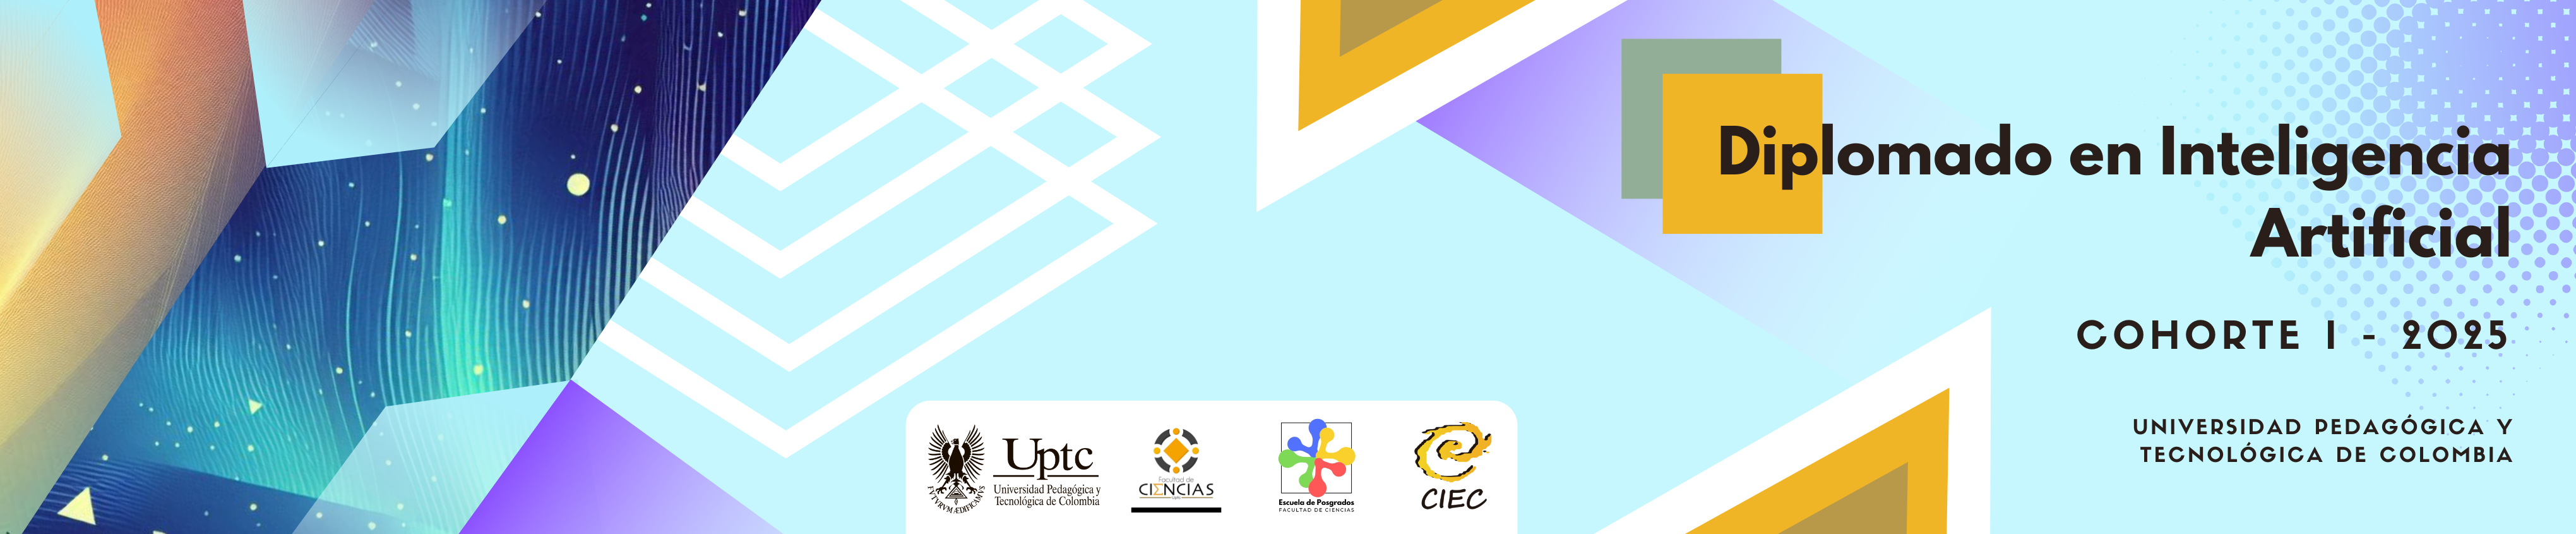

<!-- Main Title -->

**<h1 style="color: #f0b526; text-align: center;"> Regresión Lineal </h1>**

---

**<h2 style="color: rgb(71, 207, 228);">Autores</h2>**

- [Nicolás Castillo Ojeda](https://www.linkedin.com/in/nicolas-castillo-ak/)

---

<!-- Table of Contents -->
**<h2 style="color: rgb(71, 207, 228);">Tabla de contenido</h2>**

- [<span style="color: rgb(45, 164, 182);">1. Regresión Lineal: Definición matemática y principios computacionales</span>](#section1)
  - [<span style="color: rgb(42, 100, 109);">1.1. Hipótesis de representación y función de costo</span>](#subsection11)
  - [<span style="color: rgb(42, 100, 109);">1.2. Optimización de la función de costo</span>](#subsection12)
- [<span style="color: rgb(45, 164, 182);">2. Caso de aplicación</span>](#section2)
  - [<span style="color: rgb(42, 100, 109);">2.1. EDA</span>](#subsection21)
  - [<span style="color: rgb(42, 100, 109);">2.2. Preprocesamiento</span>](#subsection22)
  - [<span style="color: rgb(42, 100, 109);">2.3. Partición de los datos</span>](#subsection23)
  - [<span style="color: rgb(42, 100, 109);">2.4. Modelamiento</span>](#subsection24)
  - [<span style="color: rgb(42, 100, 109);">2.5. Evaluación de desempeño</span>](#subsection25)
- [<span style="color: rgb(45, 164, 182);">3. Parámetros de regresión y significancia</span>](#section3)

---

**<h2 style="color: rgb(71, 207, 228);">Introducción</h2>**


Bienvenido al curso de "*Regresión Lineal*". La regresión lineal es una de las técnicas más fundamentales en Machine Learning y Ciencia de Datos, utilizada para modelar la relación entre una variable dependiente y una o más variables independientes. Su objetivo es encontrar el mejor hiperplano que prediga los valores de salida minimizando el error entre las predicciones y los valores reales, generalmente mediante el método de mínimos cuadrados. Esta técnica es crucial en diversas aplicaciones, desde la predicción de precios y tendencias económicas hasta la modelización de fenómenos científicos y el análisis de datos en negocios o biológicos.  

Para comprender que es una regresión lineal, es esencial dominar conceptos como el descenso del gradiente, entender que son las variables dependientes e independientes. Verémos cómo mediante el cálculo diferencial es posible determinar coeficientes de regresión, parámetros que definen al modelo. Posteriormente entenderemos cómo evaluar el desempeño de un modelo de regresión lineal junto con las técnicas indispensables para evitar un problema muy común en machine learning: el sobreajuste.

---

**<h2 style="color: rgb(71, 207, 228);">Dependencias</h2>**

In [2]:
# Manipulación de datos
import numpy as np
import pandas as pd
# Visualización de datos
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Calculos estadísticos
from scipy import stats

# Preprocesamiento de datos
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler 
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split

# Modelamiento
from sklearn.linear_model import LinearRegression
import statsmodels.regression.linear_model as sm

# Métricas de evaluación
from sklearn.metrics import  mean_squared_error, mean_absolute_error, r2_score

# Control autónomo de las advertencias
import warnings
warnings.filterwarnings("ignore")

C:\Users\Usuario\AppData\Roaming\Python\Python310\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [3]:
%load_ext autoreload
%autoreload 2

# <!-- Section 1 -->
**<h2 id="section1" style="color: rgb(71, 207, 228);">1. Regresión Lineal: Definición matemática y principios computacionales</h2>**

### <!-- Subsection 1.1 -->
**<h3 id="subsection11" style="color: rgb(42, 100, 109);">1.1. Hipótesis de representación y función de costo</h3>**

---
Definición de la regresión lineal como espacio de hipótesis

---

La regresión lineal es un modelo de machine learning de carácter **supervisado** que pretende a través de una combinación lineal de las variables independientes escaladas por coeficientes, explicar los valores de una variable dependiente u objetivo de caracter numérico contínuo. Este tipo de modelos establece que dados los coeficientes del modelo, bajo el principio de minimos cuadrados orginarios ($OLS$) la cual es una técnica de optimización de funciones de error fundamentada en el descenso del gradiente, es posible deducir un valor plausible para tales coeficientes inicialmente desconocidos.

De manera general, los modelos de aprendizaje supervisado clásicos como la regresión lineal, tienen su fundamento matemático en la teoría de la estadística inferencial. Concretamente, Los elementos escenciales dentro de una tarea de regresión general son:

* Conjunto de datos con etiquetas numéricas:
$$
D = \{(x_1, y_2), (x_2, y_2), \ldots, (x_m, y_m)\}
$$
* Definición del vector de características:
$$
x_i = \begin{bmatrix} x_{i1} \\ x_{i2} \\ \vdots \\ x_{in} \end{bmatrix}
$$

* Matriz de características:
$$\mathbf{X} =
\begin{pmatrix}
 x_{11} & x_{12} & \cdots & x_{1 n} \\
 x_{21} & x_{22} & \cdots & x_{2n} \\
 \cdots \\
 x_{1m} & x_{2m} & \cdots & x_{mn}
\end{pmatrix}
$$

* Definición de la variable objetivo como números:
$$
y_i \in \mathbb{R}
$$

* Definición de un modelo matemático o función que permita establecer la relación entre las características y la variable objetivo:
$$
y = f(x)
$$ 

En este sentido, dada una tupla observación-etiqueta $(x^{(i)}, y^{(i)})$ con $x^{(i)}$ teniendo $n$ dimensiones, es conocida como un **ejemplo de entrenamiento**. Si se supone un espacio de funciónes de hipótesis explicativas $\mathbf{h}$ tal que una configuración específica de los parámetros $W$ de los cuales $\mathbf{h}$ es dependiente, representan una de las posibles funciones que pueden establecer una relación plausible entre $x^{(i)}$ y $y^{(i)}$. En este sentido, se tiene que $n$ = 1:

$$
\mathbf{h}_{W}(x_i) = w_0 + w_1 x_i = y_i
$$   

Donde $W = (w_0, w_1)$ son los parámetros de hipótesis, donde el modelo anterior corresponde a un modelo de **regresión lineal simple** o univariada (ya que solo depende de una variable dependiente) y se tiene que $w_1$ representa la inclinación de la recta o factor de multiplicación de la entrada $x_i$ mientras que $w_0$, conocido también en machine learning como el parámetro **bias**, se interpreta como el intercepto de la recta con el eje $y$. Por convensión, $w_0$ tambíen es denotado por $b$.

Por otra parte, si la cantidad de dimensiones $n$ > 1, la regresión lineal es conocida como **regresión lineal múltiple o multivariada** debido a que la variable objetivo o dependiente, es explicada a partir de múltiples variables de entrada o independientes. De esta manera, la función de hipótesis se denota como:

$$
\mathbf{h}_{W}(x_i) = b + w_1 x_{i1} + w_2 x_{i2}  + ... + w_j x_{ij} + ... w_n x_{in}  = y_i
$$   

Hipótesis que es equivalente a:

$$
y = \mathbf{h}_{W}(X) = W^T X + b
$$

En donde $W$ es el vector de parámetros del modelo, donde si agregamos una columna extra (una nueva "dimensión") a la matriz de características $X$ compuesta por solo unos, la ecuación anterior es equivalente a:

$$
\hat{W} = \left (\begin{matrix} w_0 \\ w_1 \\ .\\.\\ w_j\\.\\.\\ w_n \end {matrix}\right)_{(n+1,1)} 
y = \left (\begin{matrix} y_1\\ y_2\\. \\. \\ y_i \\. \\. \\ y_m \end{matrix} \right)_{(m,1)}$$

$$
y = \mathbf{h}_{\hat{W}}(X) = \hat{W}^T X
$$

Con lo anterior en mente, nuestro objetivo es determinar una serie de coeficientes $\hat{W}$ que mejor expliquen la variable dependiente a partir de las variables independientes. Para ello, debemos contar con dos elementos a parte del modelo lineal mostrado anteriormente:

* Una función de costo o pérdida que permíta cuantificar la discrepancia entre los valores arrojados por el modelo lineal $\hat{y}$ y los valores reales observados $y$ para una combinación paramétrica $\hat{W}$ dada.

* Un método de búsqueda que nos permíta mediante la identificación del valor mínimo de la función de pérdida, reconocer la combiación paramétrica óptima $\hat{W}^*$.

Verémos en parrafos siguientes que el segundo elemento necesario corresponde a la implementación de alguna ténica de optimización de funciones la cuál se traduce en la implementación de un gradiente descendente llevado a cabo sobre la función de périda con respecto a unas variables de entrada $\hat{W}$ de las cuales la función de costo ha de depender. No obstante, debemos establecer una hipótesis que nos permíta deducir de manera correcta tal función de costo.

---
Estimación de la función de costo de la regresión lineal mediante MLE

---

El **Maximum Likelihood Estimation (MLE)** es un método fundamental en estadística inferencial empleado para estimar los parámetros de un modelo probabilístico. El objetivo del MLE es encontrar los valores de los parámetros que maximizan la **verosimilitud** de los datos observados, es decir, aquellos **parámetros que hacen que los datos observados sean más probables bajo un espacio de hipótesis dado**, donde la **verosimilitud** es una medida cuantitativa  de que tan bien un conjunto de parámetros explica los datos observados.

Supongamos que tenemos un conjunto de datos $\mathbf{X} = \{x_1, x_2, \dots, x_n\}$ y que estos datos provienen de una distribución paramétrica con función de densidad de probabilidad (pdf) $f(\mathbf{X}; \theta) $, donde $\theta$ es un vector de parámetros desconocidos que queremos estimar y donde $\mathbf{X}$ es la matriz que representa el conjunto de datos que disponemos.

Concretamente, la **verosimilitud** es la probabilidad de observar el conjunto de datos $\mathbf{X}$ dados los parámetros $\theta$. Si se asume que cada observación es independiente una de la otra, la función $f(x_i,\theta)$ da la probabilidad de que el dato puntual $x_i$ ha sido generado por el modelo matemático dependiente de los parámetros de interés. Así pues, si queremos tener un panorama a cerca de la probabilidad total de que dados unos parámetros se generen unas observaciones, la función de verosimilitud es el **producto de las probabilidades independientes de cada observación**:

$$
L(\theta; \mathbf{X}) = P(\mathbf{X} | \theta) = \prod_{i=1}^{n} f(x_i; \theta)
$$

El MLE busca mediante el calculo diferencial aquellos valores de $\theta$ que maximizan esta función de verosimilitud. Es decir, la combinación de parámetros que maximizan la probabilidad de que unos datos puedan llegar a ser observados dados un modelo. Esta se encuentra mediante una optimización de la función estadística objetivo (se pretende buscar un máximo dentro de la función de verosimilitud):

$$
\hat{\theta}_{\text{MLE}} = \text{argmax}_{\theta} \ L(\theta; \mathbf{X})
$$


Para simplificar los cálculos, es conveniente usar una función objetivo más sencilla de manejar, en lugar de maximizar la verosimilitud directamente a menudo se maximiza su logaritmo conocido como la **log-verosimilitud**. Esto es posible porque el logaritmo es una función monótona creciente lo que implica que al maximizar la log-verosimilitud se realiza un proceso equiparable al maximizar la verosimilitud, de manera tal que al encontrar el máximo de la log-verosimilitud se está determinando el máximo de la función de verosimilitud.

$$
\ell(\theta; \mathbf{X}) = \log L(\theta; \mathbf{X}) = \sum_{i=1}^{n} \log f(x_i; \theta)
$$

El estimador MLE se encuentra entonces maximizando la log-verosimilitud, problema formulado de la siguiente manera:

$$
\hat{\theta}_{\text{MLE}} = \text{argmax}_{\theta} \ \ell(\theta; \mathbf{X})
$$


El MLE (Maximum Likelihood Estimation) es una técnica probabilística que si bien asume la completa independencia de los datos, es lo suficientemente poderosa como para construir un estimdor puntual de parámetros para una enorme variedad de modelos. En la presente subsección, ilustraremos por que el problema canonico dentro del Machine Learning, la regresión lineal, no solo está sustentado por las herramientas del cálculo diferencial sino que a su vez, por la teoría de la probabilidad y la estadística.

En este sentido, la lección más valiosa que podrémos ver en éste módulo (a parte del modelamiento de datos usando regresion lineal) es el **origen de la función de error para los problemas de regresion dentro del machine learning en general**. Si bien esta función de error u objetivo proviene en un inicio del problema de regresión lineal, su definición cuadrática permíte ser aplicada a múltiples problemas y modelos dentro del aprendizaje automático e incluso dentro del aprendizaje profundo ya que es una función localmente convexa que permíte dar una solución aproximada a todo problema de regresión.

La formulación de la regresión lineal desde la probabilidad es la siguiente: suponiendo que tenemos un conjunto de datos $X = \{x_i,y_i\}_i^m$ donde $m$ es el número de datos, $x_i$ es el valor de la variable independiente para el dato $i$ (conocida) y $y_i$ el valor de la variable independiente del dato $i$ tal que el conjunto de datos $X$ en su colectivo con respecto a la variable objetivo sigue una tendencia lineal, podemos suponer que nuestra hipótesis corresponde a que dichos datos obedecen a un modelo lineal que posee cierta discrepancia o **ruido/error** en comparación de la linealidad perfecta, relación lineal dada por la expresión:

$$
y_i = w_0 + w_1 x_i + \epsilon_i
$$

Donde $w_0$ y $w_1$ son respectivamente los parámetros del modelo a estimar en el caso univariado, siendo $w_0$ el intercepto con el eje $y$ y $w_1$ la inclinación de la recta en el contexto de un plano cartesiano. Nuestra hipótesis a demás, se basa en el hecho de que el valor real para la variable dependiente para cada observación $y_i$, corresponde a una combinación lineal de los parámetros anteriormente nombrados y lad variabled  de entrada $x_i$ más un **término de error** (error entendido como una desviación de la perfecta linealidad) $\epsilon_i$. 

Asumiendo que los errores o desviaciones $\epsilon_i$ son **independientes** e **idénticamente distribuidos** según una distribución normal con media $\mu$ igual a cero y varianza $\sigma^2$, se plantea la hipótesis de que tales desviaciones de  los valores estimados por el modelo lineal se distribuyen aleatoriamente al rededor de la linealidad perfecta de manera independiente y heterocedástica (varianza constante) de modo que:

$$
\epsilon_i \sim \mathcal{N}(\mu=0, \sigma^2)
$$
$$
P(\epsilon) = \frac{1}{\sqrt{2 \pi \sigma^2}} \exp\left(-\frac{\epsilon^2}{2 \sigma^2}\right)
$$

La imágen a continuación, ilustra la formulación probabilística de la regresión lineal, donde se asume que la desviación del $y$ verdadero se debe a causa de que este punto puede en principio ser reproducido si se hace algún muestreo aleatorio a partir de una distribución normal centrada en el modelo lineal, donde note entonces que el modelo lineal es la **tendencia promedio de los datos**.



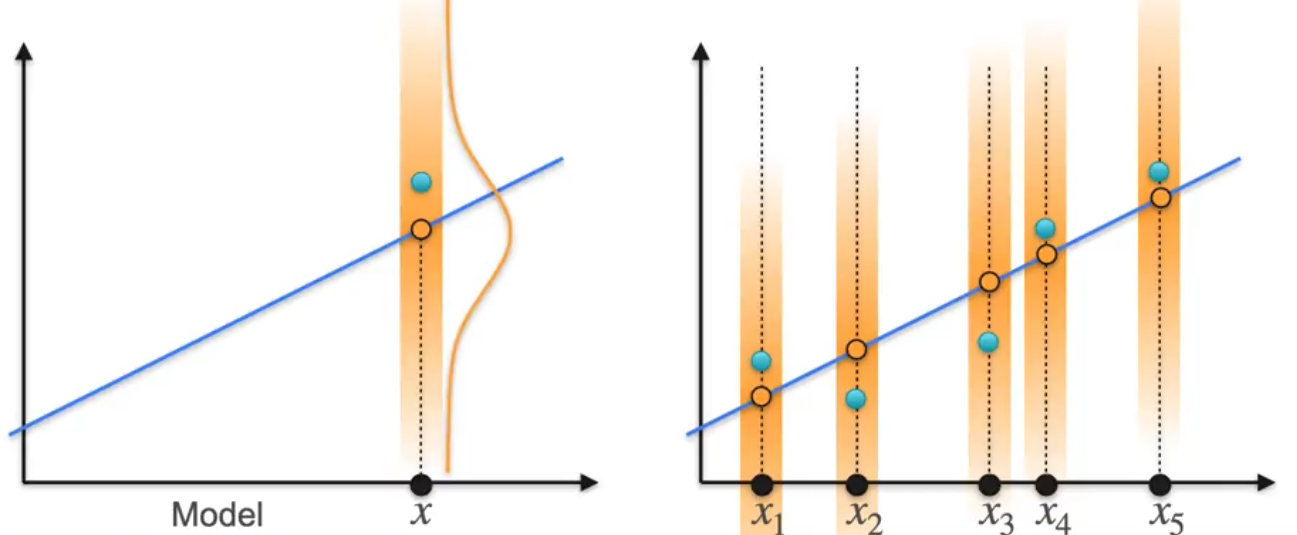

Con lo anterior en mente, si la distancia entre la estimación del modelo lineal para la entrada $x_i$ , $\hat{y}_i$, y el verdadero valor en los datos para la variable $y$ en el punto $i$, $y_i$, es $d_i = \hat{y}_i - y_i$, podémos traducir la probabilidad de producir el valor $y_i$ al rededor de la tendencia lineal central (donde las gaussianas están centradas) como la probabilidad de obtener el valor $\epsilon_i = d_i$ centrado en nuestro modelo lineal. Así pues, la probabilidad de obtener la $i$-ésima distancia entre los valores reales y las estimaciones es simplemente:

$$
P(y_i|x_i,w_0,w_1) = P(d_i) = \frac{1}{\sqrt{2 \pi \sigma^2}} \exp\left(-\frac{d_i^2}{2 \sigma^2}\right)
$$

Donde en términos del modelo, se tiene:

$$
d_i = y_i - (x_i w_1 + w_0)
$$

Si ahora consideramos todos los datos posibles, asumiendo la independencia de las observaciones, construimos la función de verosimilitud como: 

$$
L(w_0,w_1;X) = P(Y|X,w_0,w_1) = \prod_{i=1}^{n} P(y_i|x_i,w_0,w_1)
$$

Como $y_i$ sigue una distribución normal, la función de densidad para cada $ y_i $ es:

$$
L(w_0, w_1; X) = \prod_{i=1}^{n} \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{(y_i - w_0 - w_1 x_i)^2}{2\sigma^2}\right)
$$

Para simplificar el proceso de maximización, tomamos el logaritmo de la función de verosimilitud para obtener la **log-verosimilitud**:

$$
\ell(w_0, w_1;X) = \log L(w_0, w_1; X) = -\frac{n}{2} \log(2\pi\sigma^2) - \frac{1}{2\sigma^2} \sum_{i=1}^{n} (y_i - w_0 - w_1 x_i)^2
$$


Ya que el objetivo es encontrar los valores de $w_0$, $w_1$ y $\sigma^2$  que maximicen $\ell(w_0, w_1; X)$, este problema se puede resolver tomando derivadas parciales de la log-verosimilitud con respecto a cada parámetro y luego igualando a cero para resolver el sistema de ecuaciones.

Maximicemos primero con respecto a $w_0$ y $w_1$. 

$$
\frac{\partial \ell}{\partial w_0} = \frac{1}{\sigma^2} \sum_{i=1}^{n} (y_i - w_0 - w_1 x_i) = 0
$$

$$
\frac{\partial \ell}{\partial w_1} = \frac{1}{\sigma^2} \sum_{i=1}^{n} x_i (y_i - w_0 - w_1 x_i) = 0
$$

Estas dos ecuaciones son conocidas como las **ecuaciones normales** para la regresión lineal, donde se asume un valor $\sigma^2 = 1$:

$$
\sum_{i=1}^{n} (y_i - w_0 - w_1 x_i) = 0
$$

$$
\sum_{i=1}^{n} x_i (y_i - w_0 - w_1 x_i) = 0
$$

Al resolver estas ecuaciones para $w_0$ y $w_1$, obtenemos las fórmulas conocidas para los estimadores de mínimos cuadrados ordinarios (OLS):

$$
w_1^* = \frac{\sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})}{\sum_{i=1}^{n} (x_i - \bar{x})^2}
$$

$$
w_0^* = \bar{y} - w_1 \bar{x}
$$

Donde:
- $\bar{x} = \frac{1}{n} \sum_{i=1}^{n} x_i $ es la media de $ X $,
- $\bar{y} = \frac{1}{n} \sum_{i=1}^{n} y_i $ es la media de $ y $.

En caso de que no se asuma un sigma igual a uno, para hallarlo basta simplemente con maximizar la función de log-verosimilitud con respecto a éste parámetro.

$$
\frac{\partial \ell}{\partial \sigma^2} = -\frac{n}{2\sigma^2} + \frac{1}{2\sigma^4} \sum_{i=1}^{n} (y_i - w_0 - w_1 x_i)^2 = 0
$$

Resolviendo para $ \sigma^2 $:

$$
\hat{\sigma}^2 = \frac{1}{n} \sum_{i=1}^{n} (y_i - w_0 - w_1 x_i)^2
$$

Lo cuál se puede rescribir simplemente como:

$$
\hat{\sigma}^2 = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$

Este estimador $\hat{\sigma}^2 $ es la **varianza residual** o **error cuadrático medio** la cuál es la función objetivo de la regresión lineal.

No obstante, podemos extender estos razonamientos al caso multivariable donde ahora, la función de verosimilitud es:

$$
L(\hat{W}; X) = P(Y|X,\hat{W}) = \prod_{i=1}^{n} P(y_i|x_i, \hat{W}) = \prod_{i=1}^{n} \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{(y_i - \hat{W}^T x_i)^2}{2\sigma^2}\right)
$$

Posteriormente, definimos la log-verosimilitud como:

$$
\ell(\hat{W}) = log L(\hat{W}; X) = n log \left(\frac{1}{\sqrt{2\pi\sigma^2}}\right) - \frac{1}{\sigma^2} \frac{1}{2} \sum_{i=1}^{m} \left(y_i - \hat{W}^T x_i \right)^2
$$

Donde tanto el primer término como el parámetro $\sigma^2$ son constantes, por ende, maximizar la log-verosimilitud dependerá únicamente de minimizar la función de costo basada en el error cuadrático medio (MSE):  

$$
J(\hat{W}) = \frac{1}{2} \sum_{i=1}^{n} (y_i - X_i \hat{W})^2
$$

Que en forma matricial se expresa como:  

$$
J(\hat{W}) = \frac{1}{2} (y - X \hat{W})^T (y - X \hat{W})
$$

Para encontrar el mínimo, derivamos con respecto a $\hat{W}$ y establecemos la derivada igual a cero:  

$$
\frac{\partial J}{\partial \hat{W}} = -X^T(y - X\hat{W}) = 0
$$

Resolviendo para $\hat{W}$:  

$$
X^T X \hat{W} = X^T y
$$

Finalmente, si $$ X^T X $$ es invertible, la solución analítica cerrada del problema de mínimos cuadrados es:  

$$
\hat{W}^* = (X^T X)^{-1} X^T y
$$

Esta ecuación permite calcular directamente los coeficientes del modelo sin necesidad de iteraciones, aunque en problemas con grandes volúmenes de datos, el cálculo de la inversa de $X^T X $ puede ser computacionalmente costoso.



### <!-- Subsection 1.1 -->
**<h3 id="subsection11" style="color: rgb(42, 100, 109);">1.1. Optimización de la función de costo</h3>**

---
Modelo lineal y función de Pérdida (MSE)

---

En machine learning, una función de pérdida (también conocida como función objetivo o función de costo) mide la discrepancia entre las predicciones de un modelo y los valores reales. El objetivo principal es minimizar esta función, ya que un valor menor de la función de pérdida indica que el modelo está haciendo predicciones más cercanas a los valores reales. En el contexto de una tarea de regresión lineal, la función de pérdida cuadrática es comúnmente utilizada (MSE - Mean Squared Error por sus siglas en inglés).

Supongamos que tenemos un conjunto de datos de regresión con $m$ ejemplos etiquetados (poseemos una variable objetivo) tal que $\{(x_1, y_1), (x_2, y_2), \ldots, (x_m, y_m)\}$, donde $x_i$ son las características y $y_i$ son las etiquetas, es decir, el número a predecir.

La tarea de regresión lineal es encontrar una función lineal $f(x)$ que minimice la diferencia entre las predicciones y las etiquetas reales. El modelo lineal y la función de error se definen respectivamente cómo:

* Función lineal dependiente de los parámetros $w$ y $b$:
$$ f_{w,b}(x_i) = wx_i + b $$

* Función de perdia o error cuadrático medio, donde $\theta = [w,b]$ es el conjunto de parámetros del modelo:
$$
J(\theta) = \frac{1}{2m} \sum_{i=1}^{m} (f_{w,b}(x_i) - y_i)^2
$$


El modelo lineal que emplearémos en esta sección será una regresión lineal univariado que dependerá de características $x$ tal que $x_i= a$ con  $a$ un número real (en escencia, el vector de características está constituído por solo una característica). Por ende, el modelo que representará el comportamiento de los datos se puede calcular de la siguiente manera:

In [4]:
# Modelo lineal simple (x son números y no vectores)
def f_lineal(x ,w, b):
  m = x.shape[0]
  f_wb = np.zeros(m)

  for i in range(m):
    f_wb[i] = w * x[i] + b
  return f_wb

In [5]:
# Función de error MSE
def J_cost(x, y_real, w, b):
  m = x.shape[0]
  suma_error = 0

  for i in range(m):
    y_pred = w * x[i] + b
    costo = (y_pred - y_real[i])**2
    suma_error = suma_error + costo

  costo_total = (1/(2*m)) * suma_error

  return costo_total

---
Optimización de un modelo de regresión lineal

---

Una vez construidas las expresiones para el modelo lineal y su función de error, procederemos a crear un conjunto de datos artificiales que sigan una correlación lineal y nuestro objetivo será optimizar la función de costo de modo tal que cuando determinemos su valor mínimo, éste valor nos dirá cuales son los valores de los parámetros $w$ y $b$ que mejor se ajustan a los datos.

In [6]:
# Generación de datos artificiales
np.random.seed(13)

x = np.linspace(-2,10,200)
ruido = (np.random.normal(1,0.5,len(x)))
y =  (3 * x + ruido) + 5 * ruido

data = pd.DataFrame({'Features': x , "Target": y })
data

,Features,Target
0,-2.000000,-2.137172
1,-1.939698,2.442204
2,-1.879397,0.228300
3,-1.819095,1.898151
4,-1.758794,4.758923
...,...,...
195,9.758794,34.911143
196,9.819095,34.132750
197,9.879397,38.503931
198,9.939698,35.879008


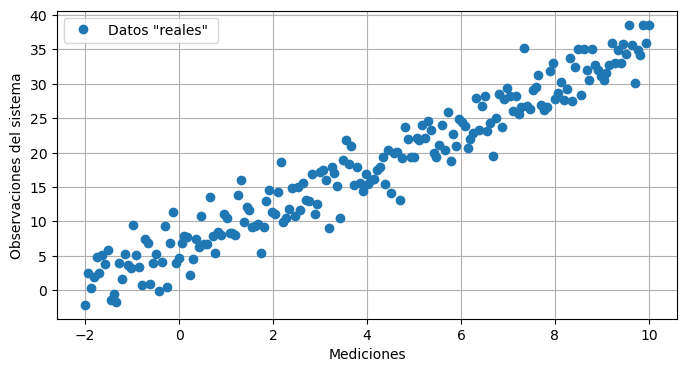

In [7]:
plt.figure(figsize=(8,4))
plt.plot(x, y, marker ='o', linestyle='None',)
plt.xlabel('Mediciones')
plt.ylabel('Observaciones del sistema')
plt.legend(['Datos "reales" '])
plt.grid(True)
plt.show()

En la sección anterior vimos que el descenso del gradiente multivariado se basa en la siguiente regla de actualiazción:

$$
  X^{(k+1)} = X^{(k)} - \alpha\nabla f|_{X=X^{(k)}}
$$

Nuestro problema de regresión lineal simple resulta ser en efecto, una aplicación del descenso del gradiente multivariable ya que al ser $J$ la función que queremos minimizar, ésta depende de dos parámetros ("variables") $w$ y $b$. De éste modo tenémos que ejecutar dos actualizaciones, una para $w$ y otra para $b$ tal que:

$$
\nabla J(w,b) = \begin{bmatrix}
    \frac{\partial J}{\partial x} \\
    \frac{\partial J}{\partial y} \\
\end{bmatrix}
$$

$$
\begin{align}
\frac{\partial J(w,b)}{\partial w}  &= \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{w,b}(x_i) - y_i)x^{(i)} \\
  \frac{\partial J(w,b)}{\partial b}  &= \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{w,b}(x_i) - y_i) \\\
\end{align}
$$

Donde la regla de actualización es:

$$\begin{align*}
\;  w &= w -  \alpha \frac{\partial J(w,b)}{\partial w} \; \newline
 b &= b -  \alpha \frac{\partial J(w,b)}{\partial b}  
\end{align*}$$


In [8]:
# Gradiente de una función de pérdida de un modelo lineal
def J_grad(x, y, w, b):
  m = x.shape[0]
  dj_db = 0
  dj_dw = 0

  for i in range(m):
    # Calculamos el gradiente para cada punto de x y y
    f_wb = w * x[i] + b
    dj_dw_i = ( f_wb - y[i] ) * x[i]
    dj_db_i = ( f_wb - y[i] )

    # Calculamos el promedio de los gradientes
    dj_dw += dj_dw_i
    dj_db += dj_db_i
    
  dj_dw = dj_dw / m
  dj_db = dj_db /m

  return dj_dw, dj_db

In [9]:
# Ciclo del Gradiente descendente

def descenso_del_gradiente(x, y, w_in, b_in, alpha, num_iter, funcion_costo, funcion_gradiente):

  J_historia = []
  p_historia = []
  
  b = b_in
  w = w_in

  for i in range(num_iter):
    # Se calcula el gradiente y se actualizan los parametros
    dj_dw, dj_db = funcion_gradiente(x, y, w, b)

    # Actualización de parámetros
    b = b - alpha * dj_db
    w = w - alpha * dj_dw

    # Se registra la historia del costo
    if i < 1000000:
      J_historia.append( funcion_costo(x, y, w, b) )
      p_historia.append( [w,b] )

    # Imprimimos el costo actual en intervalos de 10
    if i% math.ceil(num_iter/10) == 0:

      print(f"Iteration {i}: Cost {J_historia[-1]} ",
            f"dj_dw: {dj_dw}, dj_db: {dj_db}  ",
            f"w: {w}, b:{b}")

  return w, b, J_historia, p_historia


In [10]:
# Split de los datos en entrenamiento (train) y validación (test)
X = data['Features'].values
y = data['Target'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
# initialize parameters
w_init = 0
b_init = 0
# some gradient descent settings
iteraciones = 10000
tmp_alpha = 1.0e-2
# run gradient descent
w_final, b_final, J_hist, p_hist = descenso_del_gradiente(X_train ,y_train, w_init, b_init, tmp_alpha,
                                                          iteraciones, J_cost, J_grad)
print(f"(w,b) Resultado del gradiente descendente: ({w_final:8.4f},{b_final:8.4f})")

Iteration 0: Cost 112.63695895668451  dj_dw: -107.34058319770608, dj_db: -17.667584183929883   w: 1.0734058319770607, b:0.17667584183929883
Iteration 1000: Cost 3.6094044521769115  dj_dw: 0.004281288728043686, dj_db: -0.030266684636799258   w: 2.9238348471464404, b:6.017043074075778
Iteration 2000: Cost 3.608346823310492  dj_dw: 5.320929113941109e-05, dj_db: -0.0003761645001924219   w: 2.9142199306650607, b:6.085015982103427
Iteration 3000: Cost 3.60834665994542  dj_dw: 6.61302900339944e-07, dj_db: -4.6750984766696925e-06   w: 2.9141004332607032, b:6.085860772184722
Iteration 4000: Cost 3.6083466599201865  dj_dw: 8.218902336487588e-09, dj_db: -5.8103688116428744e-08   w: 2.914098948106913, b:6.085871271518979
Iteration 5000: Cost 3.6083466599201817  dj_dw: 1.021563833525363e-10, dj_db: -7.221306108640135e-10   w: 2.9140989296489246, b:6.0858714020082205
Iteration 6000: Cost 3.6083466599201817  dj_dw: 1.267885796352175e-12, dj_db: -8.974598841859915e-12   w: 2.914098929419522, b:6.08587

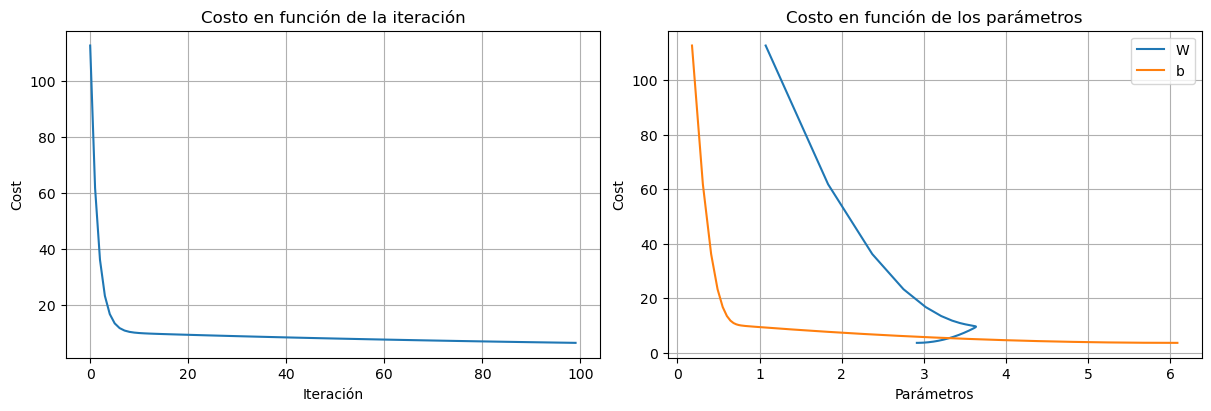

In [12]:
# Plot del entrenamiento

w_historia = [p[0] for p in p_hist]
b_historia = [p[1] for p in p_hist]
# plot cost versus iteration
fig, (ax1, ax2) = plt.subplots(1, 2, constrained_layout=True, figsize=(12, 4))

# Graficar en ax1
ax1.plot(J_hist[:100])
ax1.set_title("Costo en función de la iteración")
ax1.set_ylabel('Cost')
ax1.set_xlabel('Iteración')
ax1.grid()

# Graficar en ax2
ax2.plot(w_historia, J_hist, label='W')
ax2.plot(b_historia, J_hist, label='b')

ax2.set_title("Costo en función de los parámetros")
ax2.set_ylabel('Cost')
ax2.set_xlabel('Parámetros')
ax2.grid()
ax2.legend()  # Añadir leyenda

plt.show()


In [13]:
# Resultados
resultados = {
    'w':w_final, 'b':b_final, 'error_test': J_cost(X_test, y_test, w_final, b_final)
}
resultados = pd.DataFrame(resultados, index=[0])
resultados

,w,b,error_test
0,2.914099,6.085871,2.821721


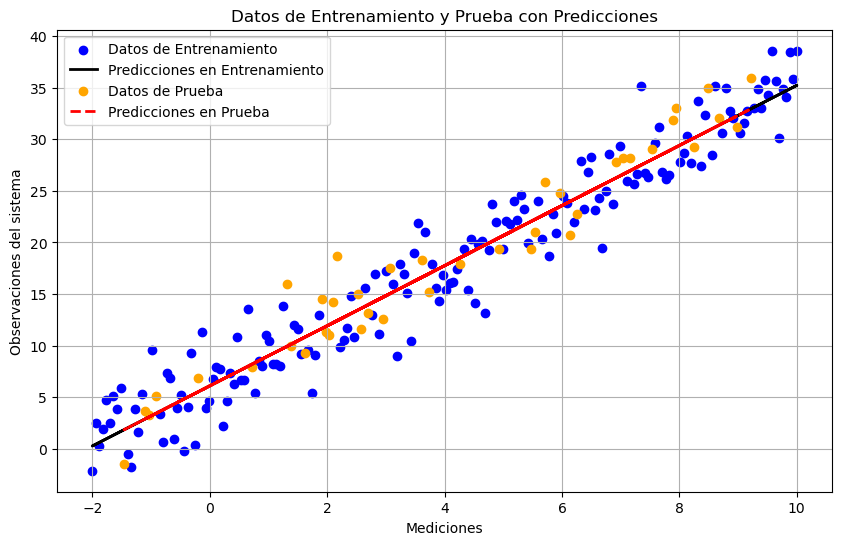

In [14]:
# Predicciones del modelo
y_train_pred = f_lineal(X_train , w_final, b_final)
y_test_pred = f_lineal(X_test , w_final, b_final)

# Graficar los datos de entrenamiento y predicciones en rojo
plt.figure(figsize=(10,6))
plt.scatter(X_train, y_train, color='blue', label='Datos de Entrenamiento')
plt.plot(X_train, y_train_pred, color='black', linewidth=2, label='Predicciones en Entrenamiento')

# Graficar los datos de prueba y predicciones en verde
plt.scatter(X_test, y_test, color='orange', label='Datos de Prueba')
plt.plot(X_test, y_test_pred, color='red', linewidth=2, linestyle='dashed', label='Predicciones en Prueba')

# Añadir etiquetas y título al gráfico
plt.title('Datos de Entrenamiento y Prueba con Predicciones')
plt.xlabel('Mediciones')
plt.ylabel('Observaciones del sistema')
plt.legend()
plt.grid(True)
# Mostrar el gráfico
plt.show()

# <!-- Section 2 -->
**<h2 id="section2" style="color: rgb(71, 207, 228);">2. Caso de aplicación</h2>**

### <!-- Subsection 2.1 -->
**<h3 id="subsection21" style="color: rgb(42, 100, 109);">2.1. EDA</h3>**

---
Análisis Exploratorio de Datos para el caso de aplicación

---

En la presente implementación de un modelo de regresión lineal a datos reales, tomaremos un conjunto de datos médicos donde nuestro objetivo será establecer una relación entre los diferentes indicadores de cada paciente y el valoer de la prima de seguro del paciente, dicho esto, las variables que manejaremos son:

- Prima del seguro
- Región donde vive el asegurado
- Indicador si fuma o no elpaciente
- Número de hijos del paciente 
- Indice de masa corporal
- Género
- Edad del asegurado

Procedemos a continuación a hacer la importación de los datos.

In [4]:
# Importación de los datos
path = './data/Insurance.csv'
df_raw = pd.read_csv(path)
df = df_raw.copy(deep=True)
print("Dimensiones del conjunto de datos =", df_raw.shape)

Dimensiones del conjunto de datos = (1338, 7)


In [6]:
# Perfilamiento general de los datos
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1337 non-null   int64  
 1   sex       1337 non-null   object 
 2   bmi       1337 non-null   float64
 3   children  1337 non-null   int64  
 4   smoker    1337 non-null   object 
 5   region    1337 non-null   object 
 6   charges   1337 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 83.6+ KB


Para empezar, generamos la tabla de descripción de los datos y observar sus métricas de resumen más importantes.

In [6]:
# Descripción estadística general
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [7]:
# Descripción estadística general de variables categoricas
df.describe(include=['object'])

,sex,smoker,region
count,1338,1338,1338
unique,2,2,4
top,male,no,southeast
freq,676,1064,364


Posteriormente, nos aseguramos de que no exístan valores duplicados ni valores nulos.

In [5]:
# Detección de valores duplicados
print('Cantidad de valores duplicados = ', df.duplicated().sum())
df.drop_duplicates(inplace=True)
print('Cantidad de valores duplicados = ', df.duplicated().sum())

Cantidad de valores duplicados =  1
Cantidad de valores duplicados =  0


In [5]:
# Detección de valores nulos
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Una vez nos hemos asegurado de que no exísten valores nulos y hemos eliminado el único dato duplicado existente, verificamos que los valores presentes dentro de cada variable tengan el formato correcto y unificado según el contexto de la variable.

In [7]:
# Verificación de formato de datos
for column in df.columns:
    print('*'*60)
    print('Columna =', column)
    print(df[column].unique())

************************************************************
Columna = age
[19 18 28 33 32 31 46 37 60 25 62 23 56 27 52 30 34 59 63 55 22 26 35 24
 41 38 36 21 48 40 58 53 43 64 20 61 44 57 29 45 54 49 47 51 42 50 39]
************************************************************
Columna = sex
['female' 'male']
************************************************************
Columna = bmi
[27.9   33.77  33.    22.705 28.88  25.74  33.44  27.74  29.83  25.84
 26.22  26.29  34.4   39.82  42.13  24.6   30.78  23.845 40.3   35.3
 36.005 32.4   34.1   31.92  28.025 27.72  23.085 32.775 17.385 36.3
 35.6   26.315 28.6   28.31  36.4   20.425 32.965 20.8   36.67  39.9
 26.6   36.63  21.78  30.8   37.05  37.3   38.665 34.77  24.53  35.2
 35.625 33.63  28.    34.43  28.69  36.955 31.825 31.68  22.88  37.335
 27.36  33.66  24.7   25.935 22.42  28.9   39.1   36.19  23.98  24.75
 28.5   28.1   32.01  27.4   34.01  29.59  35.53  39.805 26.885 38.285
 37.62  41.23  34.8   22.895 31.16  27.2   26.98  39.49

Ya que hemos descartado problemas de formato en nuestros datos, procedemos a visualizar las distribuciones y conteos de cada una de nuestras variables, es decir, ejecutamos un **análisis univariado**.

In [18]:
# Visualización individual de las distribuciones de las variables numéricas
df_numeric = df.select_dtypes(include=[int,float])
for column in df_numeric.columns:
    fig = px.histogram(
        df_numeric,
        x = column,
        marginal = 'box',
        #color_discrete_sequence = ['red'],
        title = f'Distribution of {column}'
    )
    fig.update_layout(bargap=0.1)
    fig.show()

Podemos observar de los anteriores gráficos lo siguiente:

- **Edad:** La distribución de edades es casi uniforme a excepción del rango de edades 18-19, valores que reportan un número más promimente de pacientes a comparación de otras edades.

- **BMI:** El índice de masa corporal parece comportarse muy cercanamente a una distribución normal centrada en un valor de 30. Según la OMS y recordando que el BMI es igual al cociente entre el peso de la persona sobre su altura, usualmente se tiene que para in índice $BMI < 18.5$ se considera bajo peso,
para un rango de $18.5 - 24.9$ se considera un peso normal o saludable, $25 - 29.9$ se considera un rango de sobrepeso, $30 - 34.9$ es considerado como obesidad grado 1, $35 - 39.9$ se considera obesidad grado 2 mientras que si el valor del BMI es mayor a $40$, corresponde a obesidad grado 3 o mórbida. En este sentido, se evidencia que el promedio del BMI se encuentra en el límite de obesidad grado 1, donde personas que se encuentren por debajo de este valor son consideradas como relativamente sanas mientras que aquellas que se encuentren por encima de este valor se consideran en alguna de las categorías de riesgo de salud.

- **children:** El número de hijos por paciente es monotónicamente decreciente.

- **charges:** La distribución de los costos de servicios de salud posee un sesgo positivo, lo cuál indica que si bien la mayoría de la población posee facturaciones de valor moderado (debajo de los 12000 USD), exíste una parte de la población que posee una gran facturación en sus servicios de salud, lo que implica que exíste una población de riesgo ya que han de ser personas que o bien requieren constantemente servicios de salud o tratamientos muy especializados y por ende costosos.

Debido a que la distribución de cargos de servicios de salud nos insinua que exíste una parte de la población que recurrentemente requiere servicios y por ende genera un gasto mayor, procederémos a contraponer las diferentes variables categóricas contra las variable de cargos para intentar identificar que factor es el más influyente en la necesidad de servcios de salud. Ejecutamos entonces un **análisis bivariado** sencillo.

Para este procedimiento de análisis bivariado, llevaremos a cabo las siguientes comparaciones:

* Comparación de los grupos con y sin sobrepeso de acuerdo al BMi y los cargos médicos para entender si el sobrepeso es un factor de riesgo.

* Comparación de los grupos fumadores y no fumadores según sus cargos médicos para determinar si el fumar puede representar un factor de riesgo.

* Comparación entre géneros y sus cargos médicos para determinar si según el sexo de la persona, se es más o menos propenso a requerir servicios médicos.

* Comparación entre las regiones reportadas y los cargos médicos para determinar si exíste una población de algún estado con mayor vulnerabilidad en salud.

* Comparación entre el número de hijos del paciente y los cargos médicos.

**Cargos médicos según BMI**

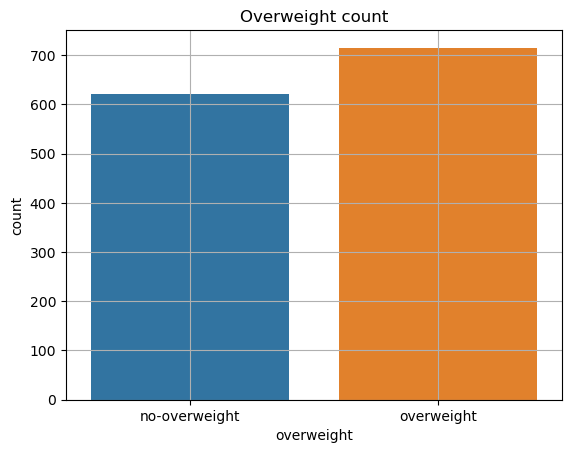

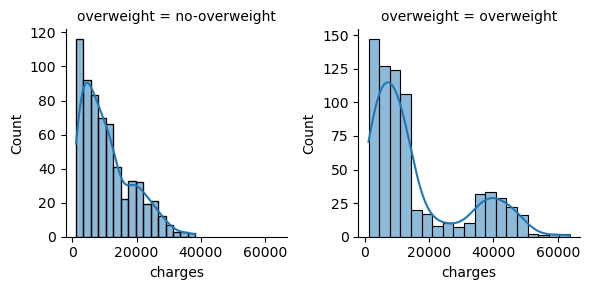

In [ ]:
# Distribución del indice de masa corporal para las personas consideradas sanas y no sanas según esta criterio
df_bmi = df.copy()
df_bmi['overweight'] = df_bmi.apply(
    lambda row: 'overweight' if row['bmi'] > 29.9 else 'no-overweight', axis=1
)

# Plot de conteo de pacientes
sns.countplot(data=df_bmi, x='overweight')
plt.title('Overweight count')
plt.grid()

# Creamos el histograma de los grupos de interés junto con un boxplot marginal de cada grupo
fig = px.histogram(df_bmi, 
                   x='charges', 
                   marginal='box', 
                   color='overweight', 
                   color_discrete_sequence=['red', 'grey'], 
                   title='Annual Medical Charges according to BMI partition')

fig.update_layout(bargap=0.1)
fig.show()

# Plot de distribucion de grupos separados
g = sns.FacetGrid(df_bmi, col='overweight', sharey=False)
g.map_dataframe(sns.histplot, x="charges", kde=True)

**Cargos médicos según si se es o no fumador**

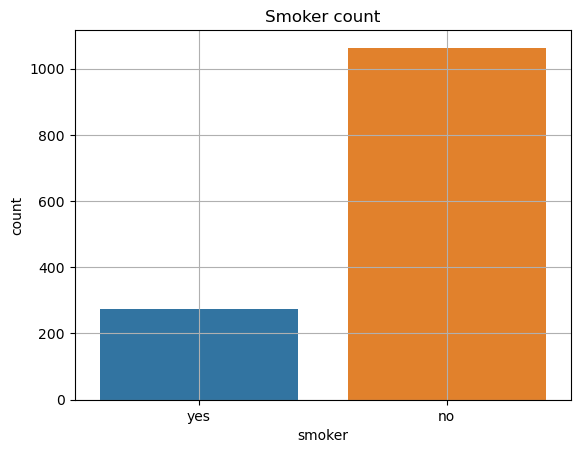

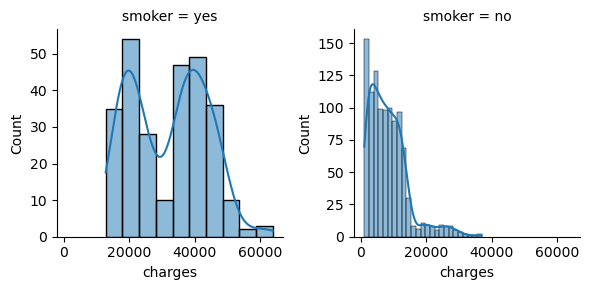

In [63]:
# Plot de conteo de pacientes
sns.countplot(data=df, x='smoker')
plt.title('Smoker count')
plt.grid()

# Distribución de cargos de salud para las poblaciones fumadoras y no fumadoras
fig = px.histogram(df, 
                   x='charges', 
                   marginal='box', 
                   color='smoker', 
                   color_discrete_sequence=['red', 'grey'], 
                   title='Annual Medical Charges for smoker and no-smoker population')
fig.update_layout(bargap=0.1)
fig.show()

# Plot de distribucion de grupos separados
g = sns.FacetGrid(df, col='smoker', sharey=False)
g.map_dataframe(sns.histplot, x="charges", kde=True)

***Cargos médicos según el sexo del paciente*

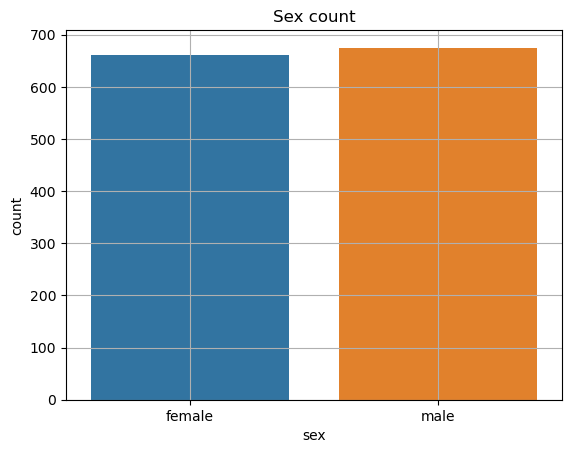

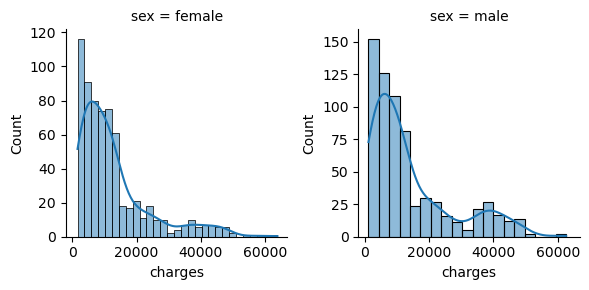

In [64]:
# Plot de conteo de pacientes
sns.countplot(data=df, x='sex')
plt.title('Sex count')
plt.grid()

# Distribución de cargos de salud según el sexo
fig = px.histogram(df,
                   x = 'charges',
                   color = 'sex',
                   marginal='box',
                   color_discrete_sequence = ["red", "blue"],
                   title = 'Different charges over genders'
               
)
fig.update_layout(bargap=0.1)
fig.show()

# Plot de distribucion de grupos separados
g = sns.FacetGrid(df, col='sex', sharey=False)
g.map_dataframe(sns.histplot, x="charges", kde=True)

**Cargos médicos según la región**

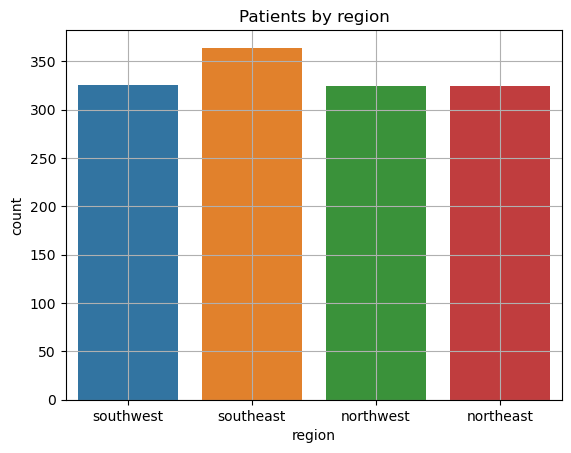

In [65]:
# Plot de conteo de pacientes
sns.countplot(data=df, x='region')
plt.title('Patients by region')
plt.grid()

# Distribución de los cargos de salud según la región de USA
fig = px.histogram(df,
                  x = "charges",
                  marginal = 'box', 
                   color="region",
                  title = "Charges over different regions of U.S.A")
fig.update_layout(bargap=0.1)
fig.show()

**Cargos médicos según el número de hijos**

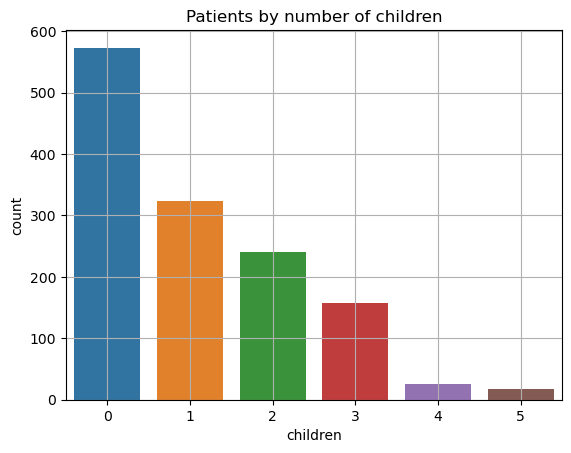

In [9]:
# Cargos con respecto al numero de hijos
fig = px.histogram(df,
                  x = "charges",
                  marginal = 'box', 
                  color="children",
                  title = "Charges according to number of children")
fig.update_layout(bargap=0.1)
fig.show()

# Plot de conteo de pacientes
sns.countplot(data=df, x='children')
plt.title('Patients by number of children')
plt.grid()

De los anteriores gráficos podemos extraer las siguientes conclusiones:

* A partir del gráfico **BMI vs charges**, es posible ver que si bien las distribuciones en término de su sesgo lucen similares, la cantidad de facturaciones por servicios de salud son  muy superiores para aquellos pacientes que presentan un BMI superior a 30, lo cúal hace sentido ya que a mayor sobrepeso mayor probabilidad de afecciones de salud existirá y por ende, más necesidad de requerir servicios de salud. Más aún, se puede concluir que personas con un BMI superior a 30 pueden incluso requerir tratamientos más costosos, lo cual indica una mayor propensión a tener affecciones de salud complicadas.

* A partir del gráfico **Smoker vs charges**, se evidencia que si bien la población fumadora requiere un menor número de servicios de salud, si requiere servicios de salud de mayor costo, lo cual puede estar asociado a la necesidad de tratamiento de afecciones de salud más complicadas para tratar que pueden generar un precio mayor en la facturación, definiendo así una clara población de riesgo.

* A partir del gráfico **Sex vs charges**, se evidencia que si bien la población femenina y masculina genera facturaciones para servicios de salud dentro del mísmo rango de valores, no discriminando así entre femenino o masculino como factor fundamental para requerir servicios de salud de alto nivel, si se observa que exíste un mayor número de facturaciones por parte de la población masculina, lo que implica que es la parte de la población que mayor necesidad de servicios de salud tiene y por ende, se puede decir que es una parte de la población más propensa a enfermedades o que cuida menos de su salud.

* A partir del gráfico **Regions vd charges**, es posible evidenciar que no existe una diferencia marcada entre las poblaciones de las regiones de USA, no obstante, si se reportan más casos de necesidad de servicios de salud para la región sureste.

* A partir del gráfico **Children vs charges**, es curioso observar que a mayor número de hijos se evidencia una menor cantidad de pacientes.

Una vez hemos identificado las poblaciones de mayor riesgo, al comparar la población fumadora según su sexo, se evidencia que la cantidad de hombres fumadores es mayor a la población femenina.

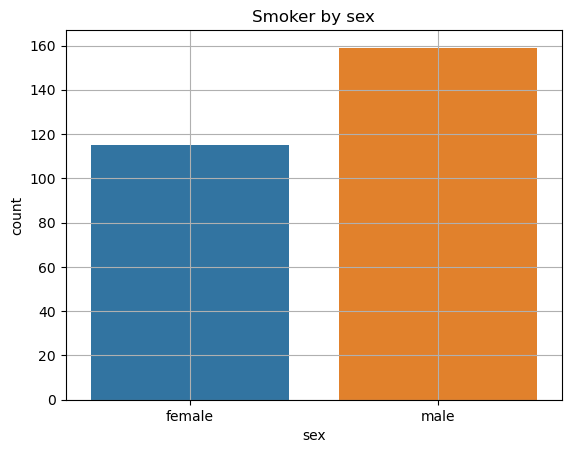

In [61]:
# Discriminación de la población fumadora
df_smoker = df[df['smoker'] == 'yes']

# Plot de conteo de pacientes
sns.countplot(data=df_smoker, x='sex')
plt.title('Smoker by sex')
plt.grid()

# Distribución de cargos de salud según el sexo
fig = px.histogram(df_smoker,
                   x = 'charges',
                   color = 'sex',
                   marginal='box',
                   color_discrete_sequence = ["red", "blue"],
                   nbins=30,
                   title = 'Different charges over genders for smoker population'
               
)
fig.update_layout(bargap=0.1)
fig.show()

Por otra parte al comparar la población fumadora según su BMI, se reportan una mayor cantidad de casos de hombres fumadores con sobrepeso que mujeres con sobrepeso. No obstante, el valor de la facturación de los tratamientos para los casos femeninos y masculinos fumadores son prácticamente los mismos, lo cual manifiesta que para ambos casos no se regístra una necesidad de tratamientos más especializados según el sexo.

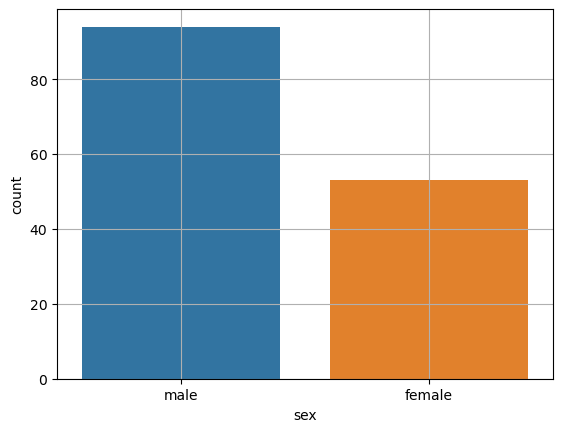

In [10]:
# Discriminación de la población fumadora
df_smoker_bmi = df_bmi[(df_bmi['smoker'] == 'yes') & (df_bmi['overweight'] == 'overweight')]

# Plot de conteo de pacientes
sns.countplot(data=df_smoker_bmi, x='sex')
plt.grid()

# Distribución de cargos de salud según el sexo
fig = px.histogram(df_smoker_bmi,
                   x = 'charges',
                   color = 'sex',
                   marginal='box',
                   color_discrete_sequence = ["red", "blue"],
                   nbins=30,
                   title = 'Different charges over genders for smoker population with overweight'
               
)
fig.update_layout(bargap=0.1)
fig.show()

In [66]:
# Conteo de población fumadora según el sexo
px.histogram(df, x='smoker', color='sex', title='Smoker by sex')

In [68]:
# Conteo de población fumadora según el sexo
px.histogram(df_bmi, x='overweight', color='sex', title='Overweight by sex')

Ya que hemos detectado que la población con sobrepeso y fumadora es aquella que mayor cantidad de servicios de salud requiere en especial para el sexo masculino, observemos ahora como al comparar los cargos de salud con respecto a la edad y dividiendo los datos en población fumadora y no fumadora, es posible evidenciar que si bien los cargos aumentan linealmente con la edad como es de esperarse (la población más vieja ha de ser más vulnerable en términos de su salud), la población fumadora suele encontrarse por encima de los cargos impuestos a pacientes no fumadores.

Por otra parte, si observamos la comparación cargos-bmi particionada según la población fumadora y no fumadora, es evidente que la población fumadora tiene una relación lineal más fuerte y pronunciada entre el bmi y el valor de sus cargos, lo cual nos permíte concluir:

- La necesidad y costos de servicios de salud es proporcional a la edad, donde esta relación lineal incremental se ubica en valores mas altos de cargos para la población fumadora.

- La necesidad y costos de servicios de salud es proporcional al BMI, no obstante esta relación se hace más lineal y más pronunciada para la población fumadora. 

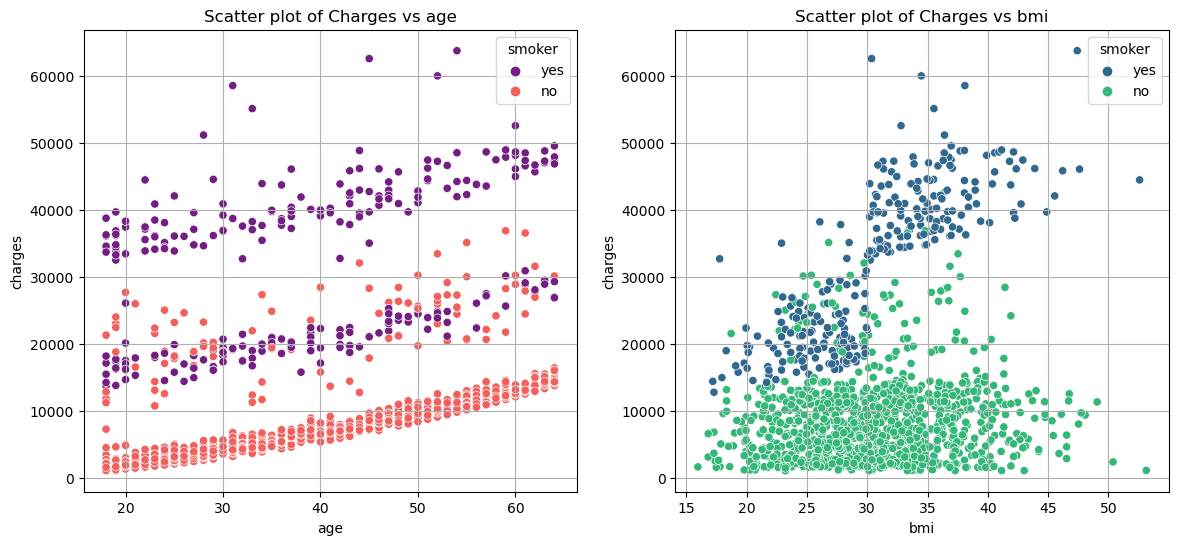

In [ ]:
# Scatter plot de comparación cargos-edad-fumador y cargos-bmi-fumador
f = plt.figure(figsize=(14,6))
ax = f.add_subplot(121)
sns.scatterplot(x='age',y='charges',data=df,palette='magma',hue='smoker',ax=ax)
ax.set_title('Scatter plot of Charges vs age')
ax.grid()

ax = f.add_subplot(122)
sns.scatterplot(x='bmi',y='charges',data=df,palette='viridis',hue='smoker')
ax.set_title('Scatter plot of Charges vs bmi')
ax.grid()

Más aún, si discriminamos entre la población fumadora con sobrepeso del resto, podemos detectar el grupo de mayor riesgo.

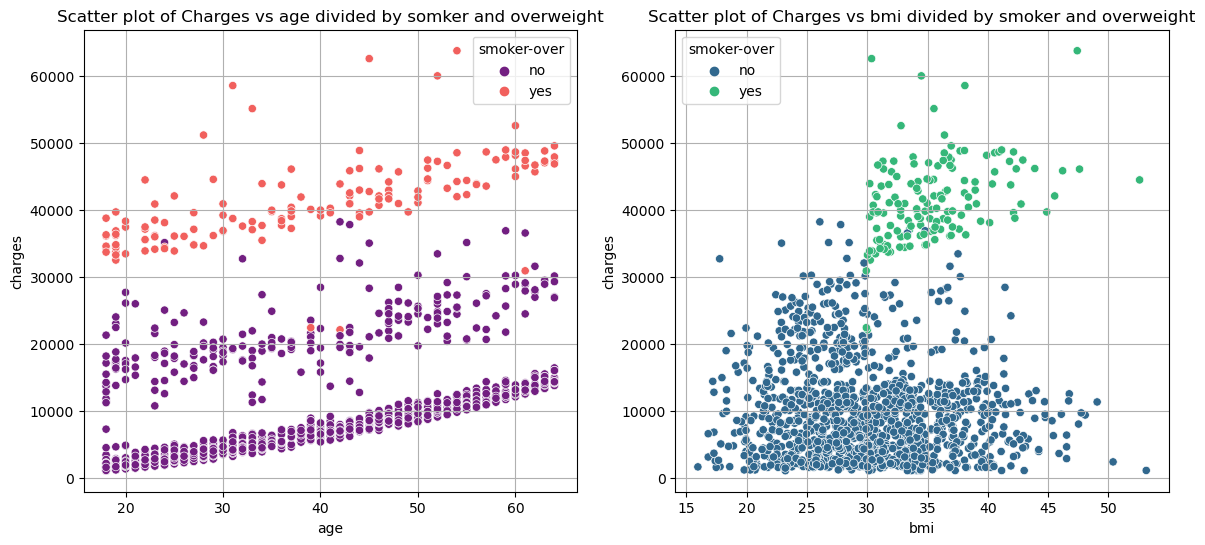

In [34]:
# Scatter plot de comparación cargos-edad-fumador y cargos-bmi-fumador para poblaciones con sobrepeso

# Discriminación de la población fumadora y con sobrepeso
df_smoker_over = df_bmi.copy()
df_smoker_over['smoker-over'] = df_smoker_over.apply(
    lambda row: 'yes' if (row['smoker'] == 'yes' and row['overweight'] == 'overweight') else 'no', 
    axis=1
)

fig = plt.figure(figsize=(14,6))
ax = fig.add_subplot(121)
sns.scatterplot(x='age',y='charges',data=df_smoker_over,palette='magma', hue='smoker-over', ax=ax)
ax.set_title('Scatter plot of Charges vs age divided by somker and overweight')
ax.grid()

ax = fig.add_subplot(122)
sns.scatterplot(x='bmi',y='charges',data=df_smoker_over,palette='viridis', hue='smoker-over')
ax.set_title('Scatter plot of Charges vs bmi divided by smoker and overweight')
ax.grid()

Por otra parte, si aislamos la población fumadora para las comapraciones anteriores y segmentamos los datos según el sexo, no se evidencia un patrón diferencial entre hombres y mujeres marcado para ninguna de las dos comparaciones.

No obstante, si tomamos la población fumadora, se evidencian dos cosas a resaltar:

- Para la comparación cargos-edad, se evidencian dos clusters de datos con correlación positiva, donde el cluster superior se ubican mayoritariamente la población fumadora con sobrepeso.

- Para la comparaicón cargos-bmi, se evidencia que al aislar la población fumadora, no solo se observa una relación lineal sino que a demás, note como a partir del humbral $BMI=30$ esta comparación presenta dos clusters de datos, donde para aquellos pacientes con BMI mayor a 30, los datos son más dispersos. De hecho, se constata que para la población fumadora con sobrepeso, los cargos de salud serán superiores a los 30000 USD.

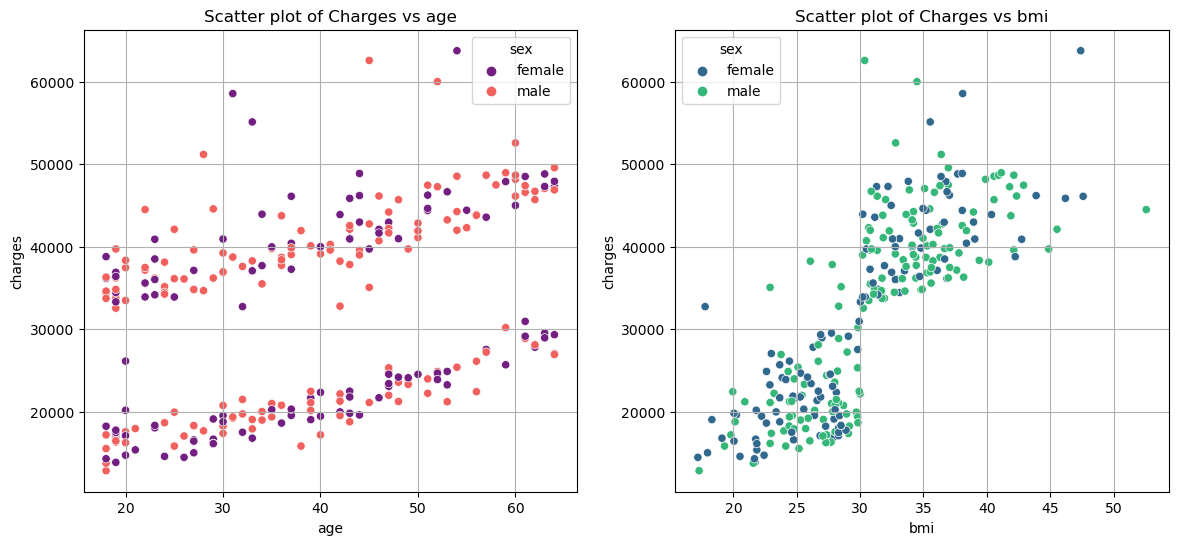

In [72]:
# Scatter plot de comparación cargos-edad-fumador y cargos-bmi-fumador
f = plt.figure(figsize=(14,6))
ax = f.add_subplot(121)
sns.scatterplot(x='age',y='charges',data=df_smoker ,palette='magma',hue='sex',ax=ax)
ax.set_title('Scatter plot of Charges vs age')
ax.grid()

ax = f.add_subplot(122)
sns.scatterplot(x='bmi',y='charges',data=df_smoker,palette='viridis',hue='sex')
ax.set_title('Scatter plot of Charges vs bmi')
ax.grid()

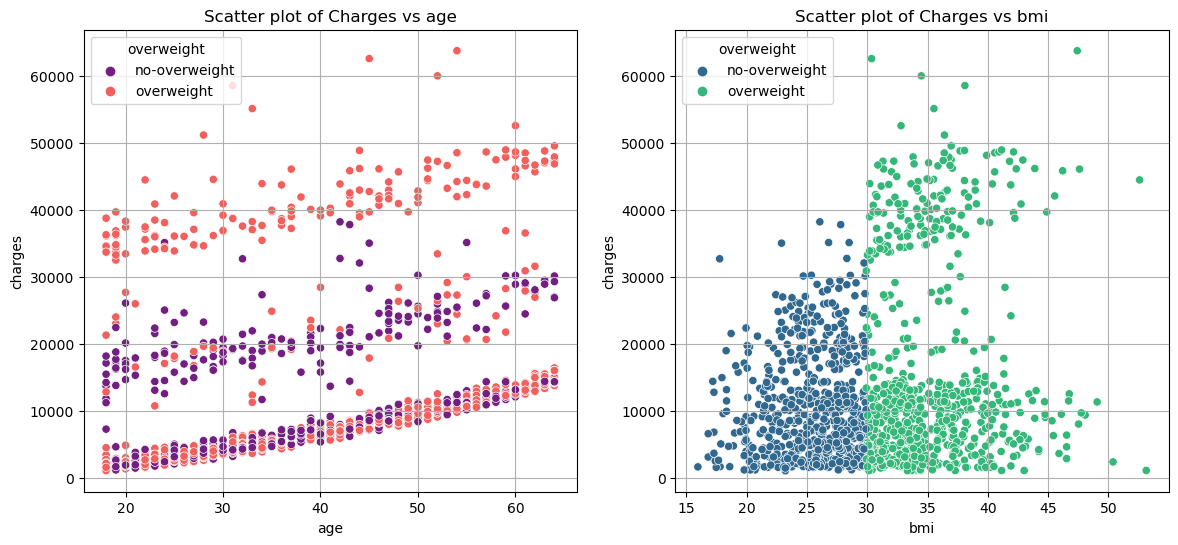

In [ ]:
# Scatter plot de comparación cargos-edad-fumador y cargos-bmi-fumador
f = plt.figure(figsize=(14,6))
ax = f.add_subplot(121)
sns.scatterplot(x='age',y='charges',data=df_bmi ,palette='magma',hue='overweight',ax=ax)
ax.set_title('Scatter plot of Charges vs age')
ax.grid()

ax = f.add_subplot(122)
sns.scatterplot(x='bmi',y='charges',data=df_bmi,palette='viridis',hue='overweight')
ax.set_title('Scatter plot of Charges vs bmi')
ax.grid()

En un problema de **regresión multivariable**, donde se modela una variable dependiente en función de múltiples variables independientes, la detección de correlación es **crucial** por las siguientes razones:  

**1. Evitar la Multicolinealidad:** La **multicolinealidad** ocurre cuando dos o más variables predictoras están altamente correlacionadas. Esto puede "inflar" la varianza de los coeficientes estimados, haciendo que el modelo sea **inestable** y los coeficientes difíciles de interpretar.  Para solucionar este problema, se deben identificar correlaciones altas y aplicar técnicas como **eliminación de variables redundantes, PCA o regularización (Ridge, Lasso).**  

**2. Mejorar la Interpretabilidad:** Un modelo con variables altamente correlacionadas puede llevar a **coeficientes engañosos**, donde el efecto de una variable se confunde con otra.  Detectar la correlación ayuda a elegir **las variables más relevantes**, mejorando la interpretación de los resultados.  

**3. Evitar Sobreajuste y Redundancia:** Si múltiples variables contienen **información redundante**, el modelo puede **memorizar en lugar de generalizar**, reduciendo su capacidad predictiva en nuevos datos.  Reduciendo la multicolinealidad, se obtiene un modelo **más simple, eficiente y robusto**.  

En nuestro caso, vemos a continuación que la correlación de las variables es baja o casi nula.

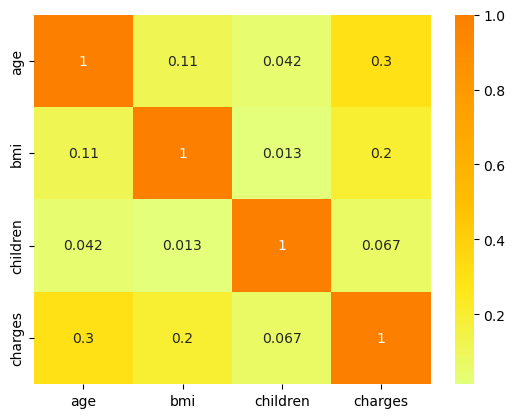

In [ ]:
# correlation plot
corr = df.select_dtypes(include=[int, float]).corr()
sns.heatmap(corr, cmap = 'Wistia', annot= True)

### <!-- Subsection 2.2 -->
**<h3 id="subsection22" style="color: rgb(42, 100, 109);">2.2. Preprocesamiento</h3>**

---
Preprocesamiento de los datos para modelamiento

---

El modelamiento de datos en machine learning no es un proceso directo o trivial en muchos casos, de hecho, una de las principales razones de importancia de la fase EDA no solo radica en extraer patrones descriptivos de los datos sino detectar que problemas podríamos llegar a tener si ingestamos un modelo de machine learning con ellos. Algunos de ellos son:

- Datos faltantes.
- Datos duplicados.
- Codificación numérica de los datos.
- Estandarización y normalización.
- Multicolinealidad.
- Desbalance de clases.
- Conversión de fechas y variables temporales.
- Presencia de outliers y sesgo en las variables independientes.

Gracias al breve proceso EDA que hemos realizado en la sección anterior es posible detectar que debemos lidiar con dos circunstancias:

- **Codificación numérica de los datos:** Los algoritmos de aprendizaje automático no suelen poder lidiar con datos categóricos, es por esto que es necesario transformar las categorías de las variables categóricas en valores numéricos de modo tal que los algoritmos de entrenamiento puedan ejecutar su proceso de optimización de pérdida.

- **Variables con alto sesgo:** El sesgo en una variable significa que sus valores están **desbalanceados, posee asimetría, están mal representados o contienen errores sistemáticos**, lo que puede afectar negativamente el desempeño del modelo.  

En especial, en nuestro caso debemos lidiar con el problema de alto sesgo en las variables:

**Riesgos del Sesgo en una Variable Independiente (Predictora)**  

- **Falta de Representatividad:** Si la variable tiene sesgo, no refleja correctamente la realidad, afectando la capacidad del modelo para generalizar.  

- **Inferencias Engañosas:** Un modelo basado en datos sesgados puede aprender relaciones falsas o distorsionadas.  

- **Sobreajuste o Subajuste:** El modelo puede depender demasiado de ciertas características irrelevantes o perder patrones importantes.  

- **Influencia excesiva de valores exremos:** Si la variable predictora tiene una **cola larga**, ciertos valores pueden dominar el entrenamiento del modelo, afectando la capacidad de generalización del modelo. Esto es especialmente problemático en algoritmos sensibles a magnitudes como la regresión lineal, SVM entre otros.

**Riesgos del Sesgo en la Variable Dependiente (Objetivo)**  

- **Predicciones Sesgadas:** Si la variable objetivo está mal etiquetada o tiene una distribución distorsionada o asimétrica, el modelo aprenderá patrones incorrectos donde las colas de las distribuciones dominarán el entrenamiento en ciertos casos dependiendo de la magnitud de los outliers.  

- **Desbalance de Clases:** En clasificación, si una clase es mucho más frecuente que otra, el modelo puede ignorar la clase minoritaria y hacer predicciones incorrectas.  



---

Numerical Encoding

---


Así pues, para empezar codificaremos de manera **One-hot-encoding** las variables categóricas, ya que todas las variables categóricas que tenemos son  **nominales**, debemos incurrir en un aumento de la dimensionalidad del dataset y no en la mera codificación numérica por medio de enteros de las variables categóricas ya que de hacerlo intentando preservar la dimensionalidad del dataset, generaremos implícitamente una jerarquía en los datos dependiente de la conveción de transformación que escojamos.

A continuación, generaremos un constructor de codificación que incorpora los procedimientos de ajuste del codificador, transformación y decodificación del dataset en un solo bloque de código.

In [6]:
# One hot encoding

class Encoder:
    def __init__(self, encoder=None, drop='if_binary'):
        if encoder is None:
            encoder = OneHotEncoder(drop=drop, sparse=False)
        self.enc = encoder 
        self.columns = None
    
    # función de codificación de los datos    
    def fit_transform(self, data, cat_columns):
        self.columns = cat_columns
        self.enc = self.enc.fit(data[cat_columns])
        enc_data = self.enc.transform(data[cat_columns])
        encoded_df = pd.DataFrame(enc_data, 
                                  columns=self.enc.get_feature_names_out(cat_columns), index=data.index)
        df = data.drop(cat_columns, axis=1).reset_index(drop=True)
        encoded_df = encoded_df.reset_index(drop=True)
        return pd.concat([df, encoded_df], axis=1)
    
    # función de decodificación de los datos 
    def inverse_transform(self, data):
        decoded_array = self.enc.inverse_transform(data, self.columns)
        decoded_df = pd.DataFrame(decoded_array, columns=self.columns)
        return decoded_df
    

In [9]:
# Codificación one-hot de nuestro dataset
one_hot_encoder = Encoder()
columns_to_encode = ['sex', 'smoker', 'region']
df_encoded = one_hot_encoder.fit_transform(df, columns_to_encode)
df_encoded.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,0.0,1.0,0.0,0.0,0.0,1.0
1,18,33.770,1,1725.55230,1.0,0.0,0.0,0.0,1.0,0.0
2,28,33.000,3,4449.46200,1.0,0.0,0.0,0.0,1.0,0.0
3,33,22.705,0,21984.47061,1.0,0.0,0.0,1.0,0.0,0.0
4,32,28.880,0,3866.85520,1.0,0.0,0.0,1.0,0.0,0.0


---

Corrección del sesgo en los datos

---

La transformación **Box-Cox** es una técnica utilizada en estadística para **hacer que los datos sigan una distribución normal a pesar de tener alto sesgo** y estabilizar la varianza de los datos. Es especialmente útil cuando se trabaja con modelos que **suponen normalidad** en los datos, como la regresión lineal o ANOVA.  La transformación Box-Cox se define como:

$$
T(y) =
\begin{cases}
\frac{y^\lambda - 1}{\lambda}, & \text{si } \lambda \neq 0 \\
\ln(y), & \text{si } \lambda = 0
\end{cases}
$$

donde se tiene que:  
* $ y $ son los datos originales (deben ser **positivos**).  
* $ T(y) $ es el valor transformado.  
* $ \lambda $ es un parámetro que se ajusta para optimizar la normalidad de los datos.  

La transformación cambia dependiendo del valor de $ \lambda $, donde según sea este valor se puede contar con cierto tipo de tranformación que "fuerza" a los datos a tener un comportamiento normal. En clases anteriores se discutió como la transformación logarítmica ayudaba a tener normalidad en los datos, sin embargo el logaritmo de los datos solo corrige sesgos positivos (cola pesada hacia la derecha), mientras que si se cuenta con sesgo negativo, una transformación logarítmica no esútil, pero Box-Cox puede elegir un $\lambda$ negativo que invierta la curvatura de la distribución:

| $ \lambda $  | Transformación resultante |
|--------------|----------------------------|
| $ \lambda = 2 $ | Cuadrado de $ y $ |
| $ \lambda = 1 $ | No hay cambio (identidad) |
| $ \lambda = 0 $ | Logaritmo natural $ \ln(y) $ |
| $ \lambda = -1 $ | Inversa $ 1/y $ |


En este sentido, las ventajas de una transformación Box-Cox son:

* Puede lidiar con sesgos tanto positivos como negativos.
* Puede estabilizar más efectivamente la varianza.
* No distorciona tanto los valores o pequeños como otras transformaciones.

---

### **¿Para qué sirve?**
1. **Normalizar los datos**: Muchos métodos estadísticos requieren que los datos sean aproximadamente normales.  
2. **Reducir la heterocedasticidad**: Ayuda a estabilizar la varianza en modelos de regresión.  
3. **Mejorar el ajuste del modelo**: Puede hacer que los modelos predictivos sean más precisos.  

A continuación, ilustramos la efectividad de esta transformación en una distribución de datos naturalmente sesgada a la derecha como lo es una distribución exponencial.

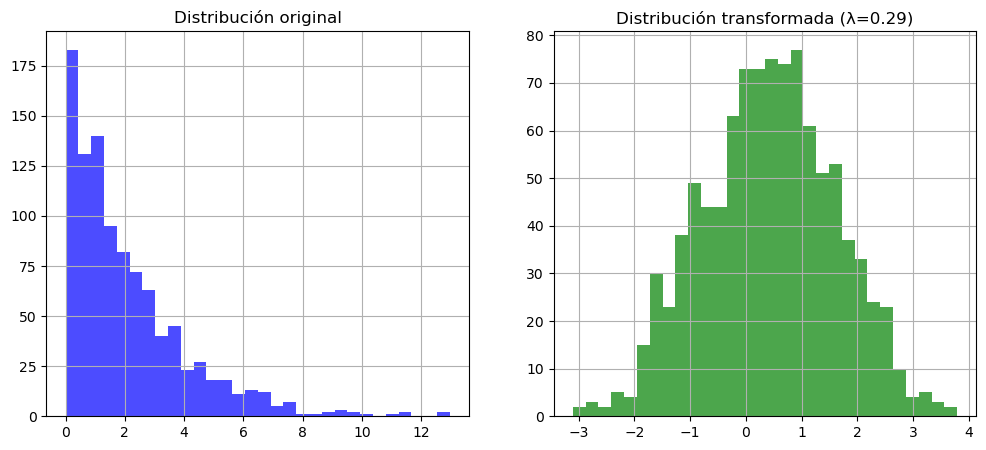

In [56]:
# Datos sesgados positivamente
data = np.random.exponential(scale=2, size=1000)

# Aplicar transformación Box-Cox
data_transformed, best_lambda = stats.boxcox(data)

# Graficar la transformación
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].hist(data, bins=30, color='blue', alpha=0.7)
ax[0].set_title("Distribución original")
ax[0].grid()
ax[1].hist(data_transformed, bins=30, color='green', alpha=0.7)
ax[1].set_title(f"Distribución transformada (λ={best_lambda:.2f})")
ax[1].grid()
plt.show()


El parámetro $ \lambda $ en la transformación Box-Cox se determina mediante un **test de máxima verosimilitud (MLE, Maximum Likelihood Estimation)**. Este procedimiento consiste en encontrar el valor de $ \lambda $ que **maximiza la verosimilitud** de los datos transformados bajo la suposición de normalidad.  

Dado un conjunto de datos $y_1, y_2, \dots, y_n $ estrictamente positivos, la transformación Box-Cox se define como:  

$$
T(y_i, \lambda) =
\begin{cases}
\frac{y_i^\lambda - 1}{\lambda}, & \text{si } \lambda \neq 0 \\
\ln(y_i), & \text{si } \lambda = 0
\end{cases}
$$

El supuesto fundamental es que los datos transformados $ T(y, \lambda) $ siguen aproximadamente una distribución normal $ \mathcal{N}(\mu, \sigma^2) $. Bajo esta hipótesis, la **función de verosimilitud** del conjunto de datos transformados es:  

$$
L(\lambda, \mu, \sigma^2) = \prod_{i=1}^{n} \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left( -\frac{(T(y_i, \lambda) - \mu)^2}{2\sigma^2} \right)
$$

Tomando el logaritmo, la **log-verosimilitud** se expresa como:  

$$
\ell(\lambda) = -\frac{n}{2} \ln(\sigma^2) - \frac{1}{2\sigma^2} \sum_{i=1}^{n} (T(y_i, \lambda) - \bar{T})^2 + (\lambda - 1) \sum_{i=1}^{n} \ln y_i
$$

Donde $ \bar{T} $ es el promedio de los valores transformados. El **valor óptimo de $ \lambda $** se obtiene **maximizando** $\ell(\lambda) $. En la práctica, esta maximización se realiza **numéricamente**, evaluando diferentes valores de $ \lambda $ y seleccionando aquel que maximiza la log-verosimilitud.




No obstante, calculamos el testo Shapiro para nuestras variables para determinar de manera cuantitativa la normalidad o no normalidad de nuestras variables.

In [12]:
# Determinamos que variables se comportan de manera normal
from scipy.stats import shapiro

columns_to_test = ['age', 'bmi', 'charges']

for column in columns_to_test:
    print('*'*60)
    stat, p = shapiro(df_encoded[column])
    if p < 0.05:
        print(f'The column {column} IS NOT normal')
        print(f'Its p value is {p}')
    else:
        print(f'The column {column} IS normal')
        print(f'Its p value is {p}')

************************************************************
The column age IS NOT normal
Its p value is 6.211415541934325e-22
************************************************************
The column bmi IS NOT normal
Its p value is 2.5783332603168674e-05
************************************************************
The column charges IS NOT normal
Its p value is 1.1960358168550093e-36


Como podemos observar, ninguna de nuestras variables sometidas a prueba de normalidad describen esta propiedad. Por ello, generaremos varios datasets para poder comparar entre los modelos que podríamos generar, entre ellos encontramos:

* Dataset sin transformación de normalidad.

* Dataset con variable dependiente transformada a la normalidad.

* Dataset con todas las variables independientes y dependientes transformadas a la normalidad.

A continuación, calculamos el valor óptimo de $\lambda$ empleando Python junto con sus intervalos de confianza.

In [13]:
# Calculo del parámetro lambda para box-cox
from scipy.stats import boxcox

df_normal_full = df_encoded.copy()
lambdas = {'column':[],
           'lambda': []}
columns_to_test = ['age', 'bmi', 'charges']

for column in columns_to_test:

    transformed_data , lambda_ = boxcox(df_encoded[column])
    lambdas['column'].append( column )
    lambdas['lambda'].append( np.round(lambda_, 4) )
    
    # Agregamos los datos transformados al dataframe
    
    df_normal_full[column + '_norm'] = np.round( transformed_data, 6 )
    
# Observamos los resultados de la transformación
lambdas 

{'column': ['age', 'bmi', 'charges'], 'lambda': [0.6251, 0.4603, 0.0435]}

In [75]:
df_normal_full.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest,age_norm,bmi_norm,charges_norm
0,19,27.900,0,16884.92400,0.0,1.0,0.0,0.0,0.0,1.0,8.479164,7.882305,12.120634
1,18,33.770,1,1725.55230,1.0,0.0,0.0,0.0,1.0,0.0,8.144206,8.806054,8.804026
2,28,33.000,3,4449.46200,1.0,0.0,0.0,0.0,1.0,0.0,11.243834,8.690111,10.141549
3,33,22.705,0,21984.47061,1.0,0.0,0.0,1.0,0.0,0.0,12.633106,6.972517,12.526076
4,32,28.880,0,3866.85520,1.0,0.0,0.0,1.0,0.0,0.0,12.361941,8.043361,9.939887


In [14]:
# Determinamos que variables se comportan de manera normal

columns_to_test = ['age_norm', 'bmi_norm', 'charges_norm']

for column in columns_to_test:
    print('*'*60)
    stat, p = shapiro(df_normal_full[column])
    if p < 0.05:
        print(f'The column {column} IS NOT normal')
        print(f'Its p value is {p}')
    else:
        print(f'The column {column} IS normal')
        print(f'Its p value is {p}')

************************************************************
The column age_norm IS NOT normal
Its p value is 4.338661267552581e-22
************************************************************
The column bmi_norm IS normal
Its p value is 0.34286922216415405
************************************************************
The column charges_norm IS NOT normal
Its p value is 3.611420537619203e-11


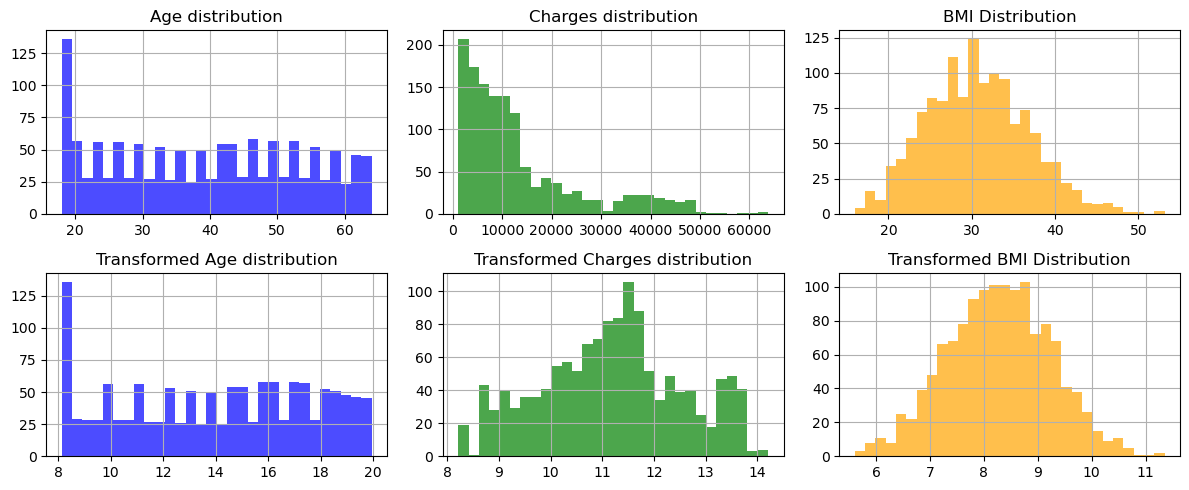

In [81]:
# Graficar la transformación
fig, ax = plt.subplots(2, 3, figsize=(12, 5))
ax[0,0].hist(df_normal_full['age'], bins=30, color='blue', alpha=0.7)
ax[0,0].set_title("Age distribution")
ax[0,0].grid()
ax[0,1].hist(df_normal_full['charges'], bins=30, color='green', alpha=0.7)
ax[0,1].set_title(f"Charges distribution")
ax[0,1].grid()
ax[0,2].hist(df_normal_full['bmi'], bins=30, color='orange', alpha=0.7)
ax[0,2].set_title("BMI Distribution")
ax[0,2].grid()
ax[1,0].hist(df_normal_full['age_norm'], bins=30, color='blue', alpha=0.7)
ax[1,0].set_title("Transformed Age distribution")
ax[1,0].grid()
ax[1,1].hist(df_normal_full['charges_norm'], bins=30, color='green', alpha=0.7)
ax[1,1].set_title(f"Transformed Charges distribution")
ax[1,1].grid()
ax[1,2].hist(df_normal_full['bmi_norm'], bins=30, color='orange', alpha=0.7)
ax[1,2].set_title("Transformed BMI Distribution")
ax[1,2].grid()
plt.tight_layout()
plt.show()


Para finalizar esta subsección, generamos los tres conjuntos de datos que hemos formulado anteriormente.

In [15]:
# Dataset con variable dependiente transformada
df_ynorm = df_encoded.copy()
df_ynorm.drop(['charges'], axis=1, inplace=True)
df_ynorm['charges_norm'] = df_normal_full['charges_norm']

# Dataset con todas las variables transformadas
df_norm = df_normal_full.drop(['charges', 'age', 'bmi'], axis=1)


### <!-- Subsection 2.3 -->
**<h3 id="subsection23" style="color: rgb(42, 100, 109);">2.3. Partición de los datos</h3>**

---

Partición de los datos

---

En cualquier proceso de modelamiento de datos por aprendizaje supervisado, particionar los datos en conjuntos de **entrenamiento** y **prueba** es fundamental para poder determinar si el modelo esta en verdad generalizando el patron fundamental de los datos o si solo esta "memorizando" tal patron, fenómeno conocido como **overfitting** (sobreajuste). Por otra parte, esta partición nos permite determinar a su vez si ocurre el fenómeno opuesto el cuál consíste en que el modelo no es lo suficientemente poderoso o flexible para explicar los datos y por el contrario, genera predicciones imprecisas a lo cuál se le conoce como **underfitting** (subajuste).

En este sentido, la estrategia de particionamiento de los datos consíste en de manera aleatoria, extraer entre el 60% al 90% de los datos de los cuales se dispone y usar tal porción como el  **training set**, subconjunto de datos bajo los cuales el modelo de aprendizaje será entrenado mientras que el porcentaje de datos restante (el cuál constituye entre el 405 y 10% del conjunto total de los datos) será empleado para evaluar el desempeño del modelo entrenado, razón por la cuál esta porción restante es denominada como  **test set**. Nuestro objetivo será pues, entrenar al modelo en una porción mayoritaria de los datos para posteriormente obligarle a que genere predicciones sobre datos nunca antes vistos por el modelo y calcular métricas de desempeño que nos permítan saber si exíste una alta, moderada o nula capacidad de generalización.

A continuación, realizaremos una partición de los datos tomando el 70% de ellos como el train set mientras que destinaremos el 30% al test set.

In [16]:
# Partición de los datos no transformados
X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, shuffle=True, random_state=42)

# Partición de los datos con variable dependiente transformada
X_yn = df_ynorm.drop('charges_norm', axis=1)
y_n = df_ynorm['charges_norm']
X_train_yn, X_test_yn, y_train_yn, y_test_yn = train_test_split(X_yn, y_n, test_size=0.3, shuffle=True, random_state=42)

# Partición de los datos con todas las variables transformada
X_norm = df_norm.drop('charges_norm', axis=1)
y_norm = df_norm['charges_norm']
X_train_norm, X_test_norm, y_train_norm, y_test_norm = train_test_split(X_norm, y_norm, test_size=0.3, shuffle=True, random_state=42)


### <!-- Subsection 2.4 -->
**<h3 id="subsection24" style="color: rgb(42, 100, 109);">2.4. Modelamiento</h3>**

---

Modelamiento de datos por medio de regresión lineal

---

Para poder determinar los parámetros de un modelo lineal podémos valernos del método analítico o numérico. El método analítico consíste en aplicar la ecuación normal de la regresión lineal dada por $\hat{W}^* = (X^T X)^{-1}X^Ty$, no obstante la posibilidad de hallar una solución cerrada al problema dependerá de la naturaleza de los datos (i.e. de la naturaleza de la matriz $X$) debido a que tal solución existirá si y solo si el producto $X^T X$ es invertible. Por esto, es más común usar un acercamiento numérico basado en descenso del gradiente  teniendo en cuenta una función de pérdida a optimizar que permíta  deducir una solución aproximada. 

A continuación emplearemos el módulo de regresión lineal de `Scikit-learn` el cuál implementa descenso del gradiente para hallar los parámetros de nuestro modelo lineal. Posteriormente, extraemos los parámetros encontrados para analizar que importancia o influencia el algoritmo de búsqueda paramétrica otorga a cada varible presente en nuestros datos. Por otra parte, ya que queremos comparar el desempeño del modelo lineal influenciado por las transformaciones numéricas que hemos efectuado hasta ahora, entrenaremos tres modelos diferentes representativos de cada caso de interés.

In [17]:
# Inicialización de los modelos lineales
lr_enc  = LinearRegression()
lr_yn   = LinearRegression()
lr_norm = LinearRegression()

# Ajuste de los modelos lineales
lr_enc.fit(X_train, y_train)
lr_yn.fit(X_train_yn, y_train_yn)
lr_norm.fit(X_train_norm, y_train_norm)

# Extracción de los parámetros obtenidos para cada modelo
lr_enc_coef = lr_enc.coef_
lr_enc_bias = lr_enc.intercept_
lr_enc_w = list(lr_enc_coef) + [lr_enc_bias]
df_w_enc = pd.DataFrame({'Column': list(X_train.columns) + ['Bias'], 
                         'W_i value': lr_enc_w})

lr_yn_coef = lr_yn.coef_ 
lr_yn_bias = lr_yn.intercept_
lr_yn_w =  list(lr_yn_coef) + [lr_yn_bias]
df_w_yn = pd.DataFrame({'Column': list(X_train_yn.columns) + ['Bias'], 
                         'W_i value': lr_yn_w})

lr_norm_coef = lr_norm.coef_ 
lr_norm_bias = lr_norm.intercept_ 
lr_norm_w = list(lr_norm_coef) + [lr_norm_bias] 
df_w_norm = pd.DataFrame({'Column': list(X_train_norm.columns) + ['Bias'],
                          'W_i value': lr_norm_w})


Una vez encontrados los parámetros del modelo lineal para cada caso, obtenemos lo siguiente.

In [25]:
# Parámetros para el modelo de datos no transformado
df_w_enc

,Column,W_i value
0,age,251.246172
1,bmi,328.383096
2,children,522.155362
3,sex_male,-111.907161
4,smoker_yes,22874.446407
5,region_northeast,541.857452
6,region_northwest,76.110856
7,region_southeast,-394.241874
8,region_southwest,-223.726434
9,Bias,-12058.638481


In [26]:
# Parámetros para el modelo de datos transformado en su variable dependeinte
df_w_yn

,Column,W_i value
0,age,0.049798
1,bmi,0.021128
2,children,0.135415
3,sex_male,-0.105568
4,smoker_yes,2.319044
5,region_northeast,0.103217
6,region_northwest,0.030273
7,region_southeast,-0.082952
8,region_southwest,-0.050538
9,Bias,8.018739


In [27]:
# Parámetros para el modelo de datos con todas las variables bajo transformación
df_w_norm

,Column,W_i value
0,children,0.124808
1,sex_male,-0.105186
2,smoker_yes,2.321836
3,region_northeast,0.104817
4,region_northwest,0.031285
5,region_southeast,-0.083271
6,region_southwest,-0.052831
7,age_norm,0.193446
8,bmi_norm,0.139373
9,Bias,6.767371


### <!-- Subsection 2.5 -->
**<h3 id="subsection25" style="color: rgb(42, 100, 109);">2.5. Evaluación de desempeño</h3>**

---
Evaluación de desempeño y análisis de resultados

---

Verémos que en una tarea de regresión general,  para evaluar el desempeño de un modelo se emplean diferentes métricas estadísticas que miden la discrepancia entre los valores predichos por el modelo y los valores reales. Dentro de las métricas de evaluación más usadas en este tipo de modelos son:

* Mean Squared Error (MSE).

* Mean Absolute Error (MAE).

* Coeficiente de determinación o R Squared.

El **MSE** mide el promedio de los errores al cuadrado entre los valores reales $ y_i $ y las predicciones $ \hat{y}_i $. Esta desviación cuadrática promedio se calcula como:

$$
MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$

Donde:
- $ n $ es el número total de observaciones.
- $ y_i $ es el valor real de la variable objetivo.
- $ \hat{y}_i $ es el valor predicho por el modelo.  

Este error **penaliza más los errores grandes debido a la elevación al cuadrado**, lo que lo hace útil cuando se quiere evitar predicciones con grandes desviaciones. Sin embargo, su interpretación no es directa porque sus unidades están al cuadrado.

Por otra parte, el **MAE** mide el error promedio entre las predicciones y los valores reales, pero en lugar de elevar los errores al cuadrado, toma su **valor absoluto**:

$$
MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|
$$

A diferencia del MSE, el **MAE** no penaliza tanto los errores grandes, lo que lo hace más robusto ante valores atípicos ya que muchas veces cuando existe unos pocos valores de discrepancia demasiado altos, éstos pueden generar un MSE no informativo debido a que estos valores atípicos opacan las contribuciones de los demás residuales lo que significa que el MSE es mas propenso a verse afectado por tales diferencias de alto valor debido al factor cuadrático. La principal ventala del MAW es que se encuentra en las mismas unidades que la variable objetivo, lo que facilita su interpretación.

Si bien el MSE y MAE son una cuantificación de la discrepancia promedio entre las predicciones y los valores objetivo, **R²** mide qué **proporción de la variabilidad total de los datos es explicada por el modelo**. Se define como:

$$
R^2 = 1 - \frac{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{n} (y_i - \bar{y})^2}
$$

Donde $\bar{y} $ es la media de los valores reales.  A diferencia del MSE y el MAE los cuales toman cualquier valor real positivo, el **R²** toma valores exclusivamente entre 0 y 1 donde:
- Un $ R^2 $ cercano a 1 indica que el modelo explica bien la variabilidad de los datos.
- Un $ R^2 $ cercano a 0 sugiere que el modelo no es bueno para predecir los valores de la variable objetivo.

Es importante mencionar que un **R² alto no garantiza un buen modelo por si solo**, ya que puede ser afectado por **sobreajuste** o por la inclusión de variables irrelevantes. De manera general, tenemos que:


| **Métrica**            | **Ventajas**  | **Limitaciones** |
|------------------------|--------------|------------------|
| **Error Cuadrático Medio (MSE)**  | - Penaliza más los errores grandes, lo que puede ayudar a detectar grandes desviaciones. <br> - Es diferenciable, lo que facilita su optimización en algoritmos de aprendizaje.  | - No es interpretable directamente en las mismas unidades de la variable objetivo. <br> - Puede ser muy sensible a valores atípicos (outliers). |
| **Error Absoluto Medio (MAE)**  | - Es fácil de interpretar porque se encuentra en las mismas unidades que la variable objetivo. <br> - Menos sensible a valores atípicos que el MSE. | - No penaliza tanto los errores grandes, lo que puede hacer que un modelo con errores grandes pero infrecuentes tenga un MAE bajo. <br> - No es diferenciable en cero, lo que puede dificultar la optimización en algunos algoritmos. |
| **Coeficiente de Determinación (R²)**  | - Indica qué porcentaje de la variabilidad de los datos es explicada por el modelo. <br> - Facilita la comparación entre diferentes modelos. | - Puede ser engañoso si hay sobreajuste o variables irrelevantes en el modelo. <br> - No informa directamente sobre la magnitud del error de las predicciones. <br> - Puede tomar valores negativos si el modelo es muy malo. |

A continuación procedemos a calcular tales métricas sobre los tres modelos entrenados.

In [18]:
# Genramos las predicciones de cada modelo
y_pred_enc_train = lr_enc.predict(X_train)
y_pred_enc_test  = lr_enc.predict(X_test)

y_pred_yn_train = lr_yn.predict(X_train_yn)
y_pred_yn_test  = lr_yn.predict(X_test_yn)

y_pred_norm_train = lr_norm.predict(X_train_norm)
y_pred_norm_test  = lr_norm.predict(X_test_norm)

In [ ]:
# Evaluación de los modelos entrenados
y_residuals = (y_test - y_pred_enc_test)
yn_residuals = (y_test_yn - y_pred_yn_test)
ynorm_residuals = (y_test_norm - y_pred_norm_test)

results = {'Model':['Just encoded', 'Y-normal', 'All normal variables'],
           'MSE_train':[],
           'MSE_test':[],
           'MAE_train':[],
           'MAE_test':[],
           'R2_train': [],
           'R2_test': []}

residual_list = [y_residuals, yn_residuals, ynorm_residuals]
y_predictions_train = [y_pred_enc_train, y_pred_yn_train, y_pred_norm_train]
y_predictions_test  = [y_pred_enc_test,  y_pred_yn_test,  y_pred_norm_test]
y_real_train        = [y_train, y_train_yn, y_train_norm]
y_real_test         = [y_test,  y_test_yn,  y_test_norm]

for i in range(len(residual_list)):
    mse_train = mean_squared_error(y_real_train[i], y_predictions_train[i])
    mse_test  = mean_squared_error(y_real_test[i],  y_predictions_test[i]) 
    mae_train = mean_absolute_error(y_real_train[i], y_predictions_train[i])
    mae_test  = mean_absolute_error(y_real_test[i],  y_predictions_test[i]) 
    r2_train  = r2_score(y_real_train[i], y_predictions_train[i])
    r2_test   = r2_score(y_real_test[i],  y_predictions_test[i]) 
    
    results['MSE_train'].append(mse_train)
    results['MAE_train'].append(mae_train)
    results['MSE_test'].append(mse_test)
    results['MAE_test'].append(mae_test)
    results['R2_train'].append(r2_train)
    results['R2_test'].append(r2_test)
    
results = pd.DataFrame(results)
results

,Model,MSE_train,MSE_test,MAE_train,MAE_test,R2_train,R2_test
0,Just encoded,3.581293e+07,3.894017e+07,4165.830851,4181.815957,0.736264,0.772436
1,Y-normal,4.384619e-01,4.002174e-01,0.417837,0.393141,0.759193,0.794249
2,All normal variables,4.363323e-01,3.950014e-01,0.420667,0.393185,0.760363,0.796931


De acuerdo a los resultados anteriores podemos concluir lo siguiente:

* Si comparamos buen sea los MSE, MAE o R2 para todos los modelos entre sus puntajes obtenidos sobre los conjuntos de train y test, vemos que los puntajes a lo largo de todos lo smodelos no son sustancialmente diferentes entre si. Si bien es natural encontrar que el puntaje en test es menor al puntaje obtenido en train, el hecho de que estos puntajes no difieran en demasiadas unidades u ordenes de magnitud tal que **score_train >> score_test** nos dice que el modelo si generaliza y no se genera un sobreajuste del modelo. 

* Al observar el coeficiente de determinación se evidencia que los modelos tienen un desempeño de entre el  $77%$ y el $79%$, donde el modelo generado a partir de un dataset transformado en todas sus variables es aquel que posee el mayor desempeño, el cual si bien representa el puntaje más elevado, es muy similar al desempeño reportado para el segundo modelo.

No obstante, la evaluación correcta de un modelo lineal no solo implica calcular una métrica que cuantifique la discrepancia entre la sitación real y los valores predichos, sino que también es necesario revisar los supuestos bajo el cuál el modelo lineal es construido:

**1. Relación lineal:** Exíste una relación lineal entre las variables independientes y la variable dependiente. Esto puede ser evaluado al generar un plot de scatter posicionando en el eje X aquellos valores reales mientras que en el eje Y, los valores correspondientes a las predicciones del modelo.

**2. Normalidad de residuales:** La distribución de los residuales del modelo lineal debe seguir una distribución normal. Esto puede verificarse mediante un **gráfico de cuantiles o una prueba Shapiro**.

**3. Homocedasticidad:** La varianza de los errores debe ser **constante**, esto puede verificarse mediante un gráfico de **residuos vs valores predichos**, donde si la dispersión aumenta o disminuye, hay heterocedasticidad. En caso de existir heterocedasticidad, es posible aplicar transformaciones o modelos más robustos.



A continuación, verificamos la linealidad de los datos.

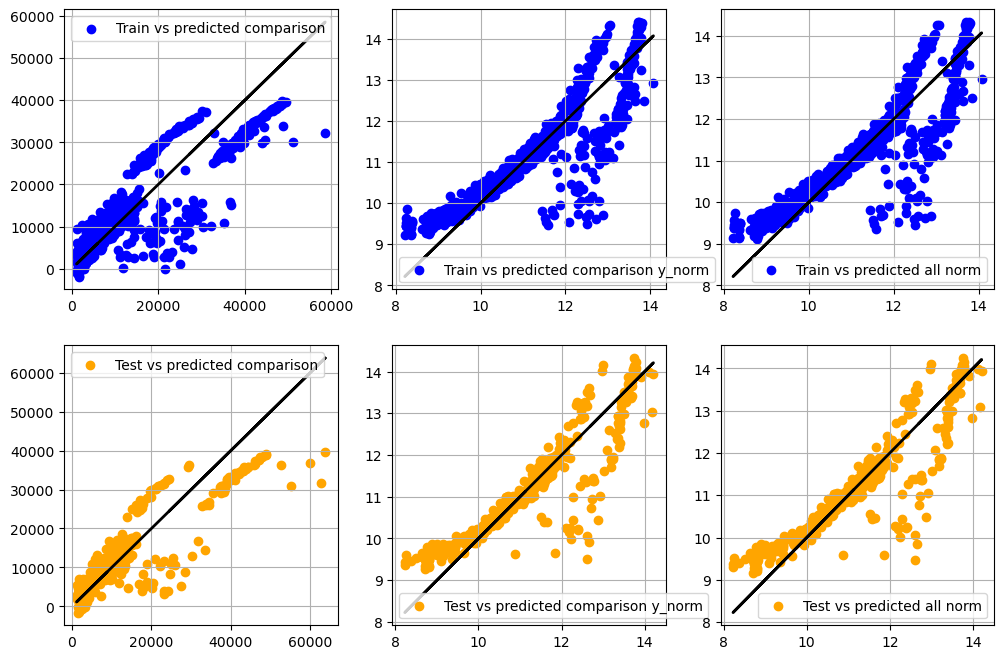

In [ ]:
# Comparación entre los valores predichos y verdaderos para la variable dependiente
fig, ax = plt.subplots(2,3, figsize=(12,8))
ax[0,0].scatter(y_train, y_pred_enc_train, color='blue', label='Train vs predicted comparison')
ax[0,0].plot(y_train, y_train, color='black', linewidth=2)
ax[0,0].grid()
ax[0,0].legend()
ax[0,1].scatter(y_train_yn, y_pred_yn_train, color='blue', label='Train vs predicted comparison y_norm')
ax[0,1].plot(y_train_yn, y_train_yn, color='black', linewidth=2)
ax[0,1].grid()
ax[0,1].legend()
ax[0,2].scatter(y_train_norm, y_pred_norm_train, color='blue', label='Train vs predicted all norm')
ax[0,2].plot(y_train_norm, y_train_norm, color='black', linewidth=2)
ax[0,2].grid()
ax[0,2].legend()

ax[1,0].scatter(y_test, y_pred_enc_test, color='orange', label='Test vs predicted comparison')
ax[1,0].plot(y_test, y_test, color='black', linewidth=2)
ax[1,0].grid()
ax[1,0].legend()
ax[1,1].scatter(y_test_yn, y_pred_yn_test, color='orange', label='Test vs predicted comparison y_norm')
ax[1,1].plot(y_test_yn, y_test_yn, color='black', linewidth=2)
ax[1,1].grid()
ax[1,1].legend()
ax[1,2].scatter(y_test_norm, y_pred_norm_test, color='orange', label='Test vs predicted all norm')
ax[1,2].plot(y_test_norm, y_test_norm, color='black', linewidth=2)
ax[1,2].grid()
ax[1,2].legend()

plt.show()

Posteriormente, generamos un plot de scatter para verificar homocedasticidad y otro gráfico de distribución para verificar la normalidad de los residuales.

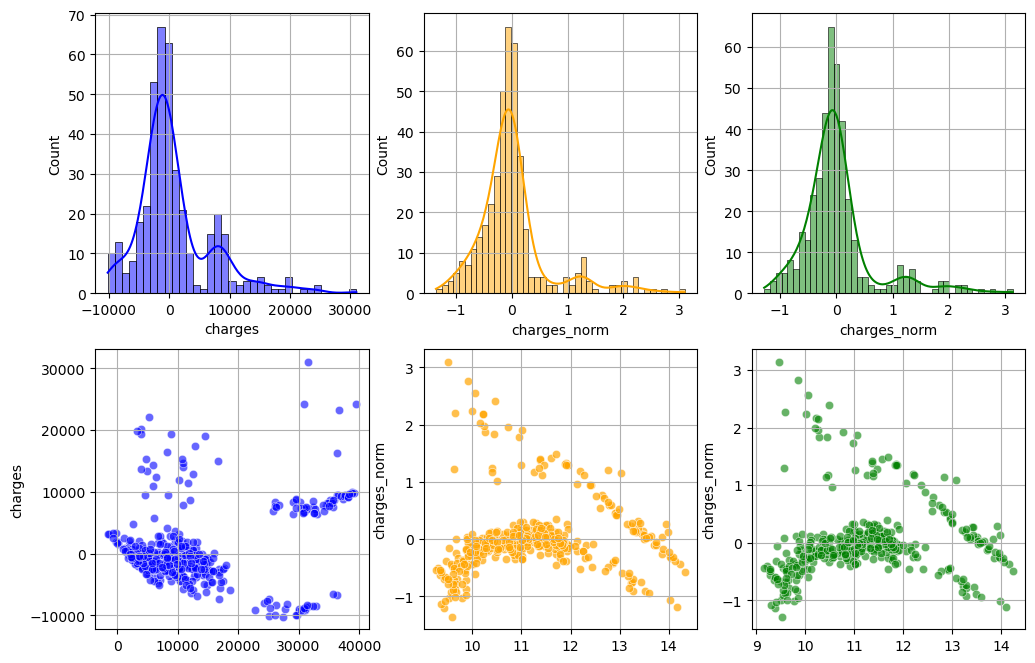

In [82]:
# Visualización de los residuales
y_residuals = (y_test - y_pred_enc_test)
yn_residuals = (y_test_yn - y_pred_yn_test)
ynorm_residuals = (y_test_norm - y_pred_norm_test)

fig, ax = plt.subplots(2, 3, figsize=(12, 8))
# distribución de los residuales
sns.histplot(y_residuals, kde=True, color='b', ax=ax[0,0])
sns.histplot(yn_residuals, kde=True, color='orange', ax=ax[0,1])
sns.histplot(ynorm_residuals, kde=True, color='green', ax=ax[0,2])
#scatter plot de los residuales
sns.scatterplot(x=y_pred_enc_test, y=y_residuals, alpha=0.6, color='blue', ax=ax[1, 0])
sns.scatterplot(x=y_pred_yn_test, y=yn_residuals, alpha=0.7, color='orange', ax=ax[1, 1])
sns.scatterplot(x=y_pred_norm_test, y=ynorm_residuals, alpha=0.6, color='green', ax=ax[1, 2])

for i in range(0,2):
    for j in range(0,3):
        ax[i,j].grid()
plt.show()

Para corroborar no solo visual sino cuantitativamente la normalidad de los residuales, generamos gráficos de cuantiles y pruebas Shapiro  para cada conjunto de residuales.

************************************************************
The residuals of the first model residuals IS NOT normal
Its p value is 2.894492237013726e-17


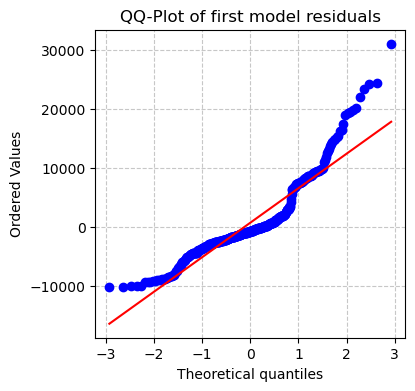

************************************************************
The residuals of the second model residuals IS NOT normal
Its p value is 1.9342466710926087e-20


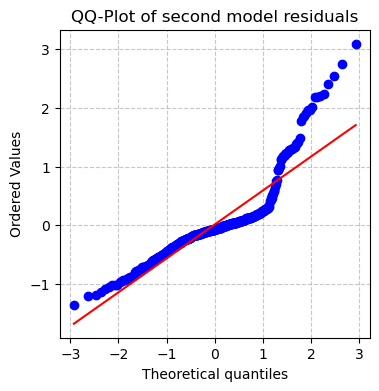

************************************************************
The residuals of the third model residuals IS NOT normal
Its p value is 1.2057242294720787e-20


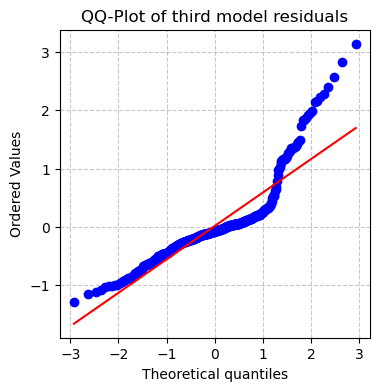

In [20]:
# Evaluación de normalidad de residuales (heterocedasticidad)

results = {'first model residuals': y_residuals,
           'second model residuals': yn_residuals,
           'third model residuals': ynorm_residuals}

for item, residuals in results.items():
    print('*'*60)
    stat, p = shapiro(residuals)
    if p < 0.05:
        print(f'The residuals of the {item} IS NOT normal')
        print(f'Its p value is {p}')
    else:
        print(f'The residuals of the {item} IS normal')
        print(f'Its p value is {p}')
    
    # Plot de cuantiles
    plt.figure(figsize=(4, 4))
    stats.probplot(residuals, dist="norm", plot=plt)
    plt.title(f'QQ-Plot of {item}')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

A partir de las anteriores formulaciones tenemos que:

* Nuestros datos no se rigen por un modelo lineal propiamente, esto es posible de determnar al analizar los plots de scatter entre los valores reales y predichos en donde se puede ver que muchos de los puntos de datos se ubican por encima o por debajo de la correspondencia perfecta, lo que implica que en algunas ocaciones los modelos lineales subestiman los valores reales o los sobrestiman.

* Las distribuciones de residuales no poseen normalidad y por el contrario, poseen sesgos positivos lo cual significa que el modelo de regresión lineal podría no estar capturando correctamente la relación entre las variables dependientes a independientes.

* Exíste heterocedasticidad, lo cual significa que los residuales  no se ubican de manera aleatoria y casi constante de manera horizontal en el plot **predicciones vs residuales** lo que implica que la varianza de los errores no es constante a lo largo de los valores de las variables predictoras. Esto viola una de las suposiciones fundamentales del modelo lineal, que asume que los errores son homocedásticos (es decir, tienen varianza constante).

Bajo este panorama, podemos concluir que:


*  A partir del coeficiente de determinación, se sugiere que el modelo explica aproximadamente el **79% de la variabilidad** de la variable dependiente, lo que en muchos contextos podría considerarse **un buen ajuste**. Sin embargo, esto no significa que el modelo sea **fiable o válido** para la toma de decisiones si las suposiciones estadísticas no se cumplen.  

* Si bien el desempeño del modelo es bueno, la falta de normalidad en la distribución de residuales formula el hecho de que las variables independientes no tienen una relación perfectamente lineal con la variable dependiente. Más aún, puede implicar que exísten valores atípicos que distorsionan el comportamiento del modelo. Por otra parte, insinúa que los coeficientes pueden estar sesgados y pueden no ser 100% confiables. Este problema puede solventarse mediante:

   - Aplicar un modelo más flexible y no lineal.
   - Aplicar transformaciones numéricas a los datos de entrada.

* La existencia de la heterocedasticidad  implica que la varianza de los errores no es constante, lo que viola una suposición elemental de la regresión lineal. Esto significa que las predicciones no son del todo confiables especialmente para valores extremos de las variables independientes. Algúnas soluciones a este problema pueden ser:

    - Transformaciones numéricas en la variable dependiente.
    - Regresión ponderada (WLS), que asigna menos peso a observaciones con alta varianza durante el proceso de entrenamiento.
    

En resumen, si nuestro objetivo es meramente la realización de predicciones, el modelo encontrado puede ser útil debido a su alto coeficiente de determinación, no obstante si se necesita realizar inferencias estadísticas (calcular intervalos de confianza para los parámetros, intervalos de confianza para las predicciones o realizar otro tipo de pruebas de hipótesis), entonces los resultados pueden ser engañosos. Por lo anterior, ha de considerarse aplicar otro tipo de transformaciones numéricas a las variables o considerar un modelo de regresión más flexible.



# <!-- Section 3 -->
**<h2 id="section3" style="color: rgb(71, 207, 228);">3. Parámetros de regresión y significancia</h2>**

---

Propiedades de los estimadores paramétricos poblacionales

---

En el contexto de la inferencia estadística, un **estimador** es una función de la muestra utilizada para proximar un parámetro o conjunto de parámetros poblacionales desconocidos. Para garantizar que un estimador sea útil en la práctica, debe cumplir cieras **propiedades deseables** las cuales aseguran su precisión y fiabilidad. Entre las propiedades más importantes se destacan la **insesgadez**, **la consistencia**, **la eficiencia**, **la suficiencia** y la **robustez**.


#### **1️. Insesgadez (Unbiasedness)**
Un estimador $\hat{\theta}$ de un parámetro $\theta$ es **insesgado** si, en promedio, su valor esperado coincide con el valor del parámetro poblacional. Formalmente se debe cumplir que:

$$
E[\hat{\theta}] = \theta
$$
  
Si un estimador es insesgado, significa que, al repetir el proceso de estimación muchas veces con diferentes muestras tomadas de la población, el valor promedio de las estimaciones tenderá al verdadero parámetro. Esta propiedad es relevante en los modelos estadísticos ya que **garantiza que el estimador no tiende sistemáticamente a sobrestimar o subestimar el parámetro.**  

#### **2. Consistencia (Consistency)**
Un estimador $\hat{\theta}_n$ es **consistente** si, a medida que el tamaño de la muestra $n$ aumenta, la estimación se aproxima al verdadero valor del parámetro con probabilidad 1. Formalmente se entiende que:

$$
\lim_{n \to \infty} P(|\hat{\theta}_n - \theta| < \epsilon) = 1, \quad \forall \epsilon > 0
$$
 
Si un estimador es consistente, significa que a medida que se recolectan más datos, la estimación mejora y se acerca al valor real del parámetro. Es una propiedad fundamental, ya que garantiza que el estimador **converge al verdadero valor en muestras grandes**.  

#### **3️. Eficiencia (Efficiency)**

Un estimador $\hat{\theta}$ es **eficiente** si tiene la menor varianza entre todos los estimadores insesgados del parámetro $\theta$. Formalmente se tiene que:

$$
Var(\hat{\theta}) \leq Var(\tilde{\theta}), \quad \forall \tilde{\theta} \text{ insesgado}
$$

Entre dos estimadores insesgados, el más eficiente es el que presenta menor dispersión en sus estimaciones de modo que un estimador eficiente aprovecha mejor la información contenida en la muestra.  


#### **4. Suficiencia (Sufficiency)**

Un estimador $\hat{\theta}$ es **suficiente** si contiene **toda la información disponible en la muestra** sobre el parámetro $\theta$. Matemáticamente, un estimador es suficiente si la distribución condicional de los datos dados el estimador no depende de $\theta$:

$$
P(X | \hat{\theta}) = P(X)
$$

Si un estimador es suficiente, no es necesario buscar información adicional en los datos para mejorar la estimación del parámetro. Permite reducir la dimensión de los datos sin perder información relevante sobre el parámetro.  Por ejemplo, en una muestra $X_1, X_2, ..., X_n$ proveniente de una distribución normal $N(\mu, \sigma^2)$, la media muestral $\bar{X}$ es un **estimador suficiente** de $\mu$.

#### **5️. Robustez (Robustness)**

Un estimador es **robusto** si **no es muy sensible** a desviaciones en las suposiciones del modelo o la presencia de valores atípicos. Un estimador robusto mantiene su validez y precisión incluso si los datos no cumplen completamente con las suposiciones del modelo. Por ejemplo, en regresión lineal, si hay **valores atípicos**, los estimadores OLS pueden ser sensibles, por lo que se pueden emplear métodos robustos como la **Regresión M-Estimators** o la **Regresión LAD (Least Absolute Deviations)**.  

Esto quiere decir que cada una de las propiedades anteriormente nombradas, garantizan:

* **Insesgadez**: garantiza que las estimaciones no estén sistemáticamente desviadas.  
* **Consistencia**: asegura que con más datos, las estimaciones mejoren.  
* **Eficiencia**: minimiza la varianza del estimador, mejorando su precisión.  
* **Suficiencia**: permite extraer toda la información relevante de los datos.  
* **Robustez**: protege contra anomalías o desviaciones de las suposiciones del modelo.  


En este sentido, en el contexto de la **regresión lineal**, el estimador poblacional de parámetros hace referencia a la técnica utilizada para obtener los valores numéricos que aproximan los coeficientes del modelo que mejor explican la relación entre las variables independientes y dependientes, es decir, corresponde al método OLS. 

Concentrandonos solamente en las primeras tres propiedades de un estimador paramétrico, es posible verificarlas mediante análisis estadísticos. Por ejemplo, dado que no conocemos los verdaderos valores $\hat{W}$, no podemos probar directamente la insesgadez. Sin embargo, podemos verificar si se cumplen los **supuestos de la regresión lineal** especialmente aquel que supone que **la media de los errores  es cero y tales errores no estan correlacionados**.

Por otra parte, si el modelo de regresión **viola alguna de las suposiciones de los Mínimos Cuadrados Ordinarios**, se puede tener un indicio de que los coeficientes tengan sesgo. Por ello, tenemos que efectuar las siguientes validaciones relacionadas con las propiedades de un estimador paramétrico:

* **Ausencia de correlación entre los errores y las variables independientes:** Es posible realizar un test **Durbin-Watson** para detectar autocorrelación en los errores.

* **Ausencia de multicolinealidad:** Se puede generar una prueba de **Factor de Inflación de Varianza (VIF)**.

* **Homoscedasticidad:** Se puede generar un test de **Breusch-Pagan**. Si hay heterocedasticidad, los errores estándar pueden estar mal estimados afectando la confiabilidad de los coeficientes.

* **Normalidad de los errores:** Se puede generar un test **Shapiro-Wilk** para saber si los errores poseen normalidad.

En el siguiente cuadro comparativo se establecen pues las relaciones entre las condiciones del modelo y las propiedades del estimador:

| **Condición**            | **Insesgadez (No sesgado)**  | **Consistencia** |  **Eficiencia** |
|------------------------|--------------|------------------|------------------|
| **Ausencia de correlación entre errores y variables independientes**  | Si los errores no están correlacionados con $X$, entonces los coeficientes estimados probablemente no esten sesgados | Si la muestra crece, la varianza del estimador se reduce. | Puede afectar la eficiencia si hay errores correlacionados con $X$ ya que se pierde información relevante | 
|**Ausencia de la multicolinealidad** | No afecta directamente el sesgo, pero si hay multicolinealidad extrema, la interpretación de los coeficientes puede ser errónea ya que estos son producto de fenómenos como la información redundante. | Si hay baja colinealidad, la varianza del estimador disminuye conforme a la muestra crece. | Alta multicolinealidad reduce la eficiencia porque hace que los coeficientes sean inestables y tengan alta varianza. |
| **Homocedasticidad** | Si la varianza de los errores es constante, el estimador se mantiene sin sesgo. | Garantiza que el estimador sigue convergiendo a los valores verdaderos con más datos. | Si se cumple, el estimador tiene mínima varianza enre todos los estimadores lineales insesgados.|
|**Normalidad de los errores** | No afecta el sesgo en muestras grandes, pero en muestras peueñas ayuda a garantizar estimaciones no sesgadas | La normalidad en los errores refuerza la convergencia del estimador.| Si se cumple, los intervalos de confianza y pruebas de hipótesis son más eficientes.| 


Para iniciar con estas corroboraciones, calculamos primero el promedio de los residuales como primer indicio de la insesgadez.

In [21]:
# Media de los errores para dar una primera hipótesis a cerca del sesgo de los parámetros

y_residuals = (y_test - y_pred_enc_test)
yn_residuals = (y_test_yn - y_pred_yn_test)
ynorm_residuals = (y_test_norm - y_pred_norm_test)

print('*'*60)
print('El promedio de los residuales del primer modelo es =', np.mean(y_residuals))
print('*'*60)
print('El promedio de los residuales del segundo modelo es =', np.mean(yn_residuals))
print('*'*60)
print('El promedio de los residuales del tercer modelo es =', np.mean(ynorm_residuals))


************************************************************
El promedio de los residuales del primer modelo es = 739.993370619611
************************************************************
El promedio de los residuales del segundo modelo es = 0.0158215290324526
************************************************************
El promedio de los residuales del tercer modelo es = 0.017948261078804206


Posteriormente, podemos generar una **Prueba de Sesgo por Simulación Booststrap**, la cual consíste en:

1. Remuestrear los datos con remplazo múltiples veces.
2. Ajustar un modelo a cada muestra y estimar los coeficientes de interés.
3. Comparar la media de los coeficientes estimados con los coeficientes originalmente hallados.
4. Si hay una diferencia sistemática, los coeficientes calculados pueden estar sesgados.

In [22]:
# Prueba de Sesgo mediante simulación Boostrap
from sklearn.utils import resample

def boostrap_bias(X, y, model, samples=1000):
    coefs = []
    for _ in range(samples):
        X_resampled, y_resampled = resample(X, y, replace=True)
        model.fit(X_resampled, y_resampled)
        coefs.append(model.coef_)
    
    general_model = model.fit(X, y)
    coefs = np.array(coefs)
    bias = np.mean(coefs, axis=0) - general_model.coef_
    var  = np.std(coefs, axis=0)
    return bias, var

Al calcular el promedio de los residuales obtenidos a partir de dos modelos diferentes, nos damos cuenta que el modelo obtenido a partir de los datos no transformados es mucho mayor. Continuemos con nuestra evaluación del sesgo en nuestros parámetros lineales mediante la prueba boostrap, donde evaluaremos la discrepancia entre el promedio obtenido para cada parámetro de la regresión lineal y el valor para tal parámetro obtenido a partir de un modelo base de comparación el cual corresponderá a aquel obtenido a partir del ajuste lineal llevado a cabo sobre el conjunto de datos por entero (haciendo alusión a un modelo determinado sobre la "población".).

In [23]:
# test de sesgo para los datos normalizados
model = LinearRegression()
bias, var = boostrap_bias(X_train_norm, y_train_norm, model=model, samples=500)

print("*"*60)
print("Sesgo estimado de los coeficientes:")
print(bias)

print("*"*60)
print("Varianza en el proceso de remuestreo:")
print(var)

************************************************************
Sesgo estimado de los coeficientes:
[ 8.79140951e-05 -3.72188466e-03  3.87050198e-03  2.39021476e-04
  1.33754968e-03  1.48998159e-03 -3.06655274e-03  5.31854430e-04
 -6.45666245e-04]
************************************************************
Varianza en el proceso de remuestreo:
[0.01619544 0.04048367 0.05878384 0.03770503 0.03745356 0.03904805
 0.03552768 0.00704902 0.02439883]


In [24]:
# test de sesgo para los datos normalizados
model = LinearRegression()
bias, var = boostrap_bias(X_train, y_train, model=model, samples=500)

print("*"*60)
print("Sesgo estimado de los coeficientes:")
print(bias)

print("*"*60)
print("Varianza en el proceso de remuestreo:")
print(var)

************************************************************
Sesgo estimado de los coeficientes:
[-3.81597830e-01  1.51732689e-02 -3.84119265e+00  1.29887040e+01
 -1.43126159e+01  1.84354601e+01 -8.17537818e+00 -2.14368257e+01
  1.11767438e+01]
************************************************************
Varianza en el proceso de remuestreo:
[ 15.72818362  38.85409276 161.29283418 378.24117806 645.05219155
 362.66913258 335.21880562 365.81816375 317.28074871]


Por otra parte, si los residuales están correlacionados con alguna variable independiente, esto indica que el modelo no ha capturado toda la información relevante de la variable independiente, lo cual puede ser un indicativo de:

* Las variables consideradas como "relevantes para el modelo" no están bien formuladas, es decir, el modelo no logra capturar bien la información de las variables.

* Los coeficientes puede que sean sesgados e inconsistentes (el modelo es sesgado).

<Axes: >

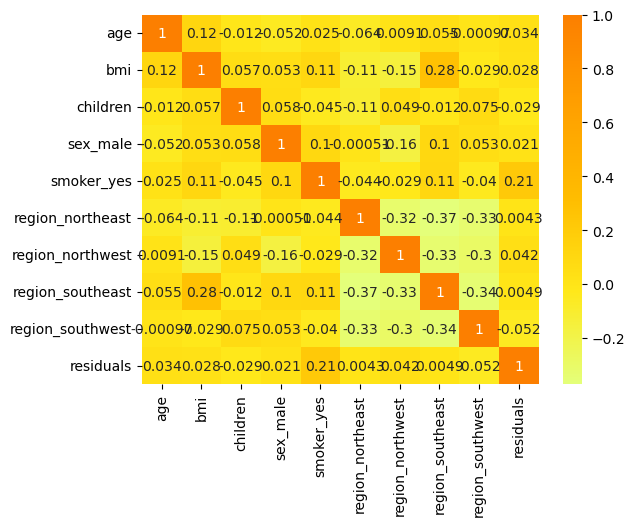

In [48]:
# Calculo de la correlación de los residuales con los valores de las variables independientes
df_residuals = pd.DataFrame(X_test)
df_residuals["residuals"] = y_residuals
matcorr = df_residuals.corr()
sns.heatmap(matcorr, cmap = 'Wistia', annot= True)

<Axes: >

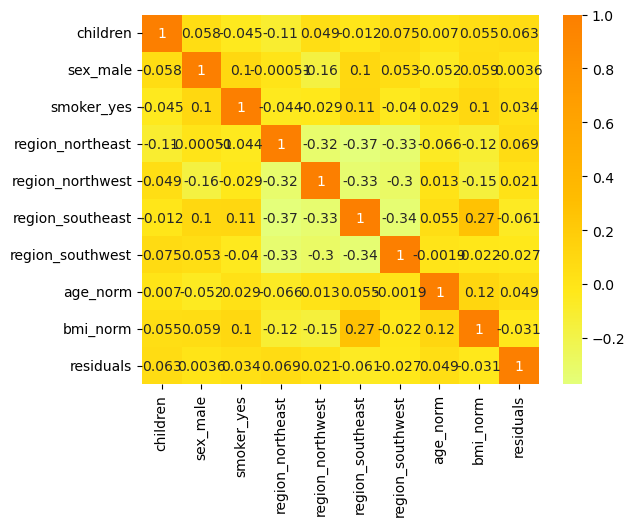

In [51]:
# Calculo de la correlación de los residuales con los valores de las variables independientes
df_residuals = pd.DataFrame(X_test_norm)
df_residuals["residuals"] = ynorm_residuals
matcorr = df_residuals.corr()
sns.heatmap(matcorr, cmap = 'Wistia', annot= True)

A partir de los gráficos de calor anteriores, vemos que no exíste una alta correlación entre los residuales y las variables independientes, por lo cual descartamos en los dos modelos testeados que exísta tal propiedad en nuestros estimadores.

El **Variance Inflation Factor (VIF)** mide el **grado de multicolinealidad entre las variables independientes en un modelo de regresión**. Indica cuánto aumenta la varianza de un coeficiente debido a la correlación con otras variables del modelo.  Para una variable independiente $X_j$, el **VIF** se define como:

$$
VIF_j = \frac{1}{1 - R_j^2}
$$

Donde $R_j^2$ es el coeficiente de determinación de la regresión de $X_j$ sobre las demás variables independientes. En otras palabras, $R_j^2$ se obtiene ajustando una regresión de $X_j$ como variable dependiente con todas las demás $X_i$ (excepto $X_j$) como regresores.  La varianza de un coeficiente estimado $\hat{w_j}$ en un modelo de regresión múltiple es:

$$
Var(\hat{w_j}) = \sigma^2 \left( X^T X \right)^{-1}_{jj}
$$

Donde $\sigma^2$ es la varianza de los residuos, $(X^T X)^{-1}_{jj}$ es el elemento correspondiente en la matriz inversa de $X^T X$. Si existe multicolinealidad, el determinante de $X^T X$ disminuye, lo que aumenta la varianza de los coeficientes estimados. Este efecto se cuantifica mediante el $VIF$, que **relaciona la varianza con el grado de colinealidad**.  Debido a que el **VIF** cuantifica cuántas veces la varianza de un coeficiente se ve aumentada debido a la multicolinealidad se tienen los siguientes rangos comúnmente usados:

- $ VIF_j = 1 $ → No hay colinealidad.  
- $ 1 < VIF_j < 5 $ → Multicolinealidad moderada.  
- $ VIF_j > 5 $ → Alta multicolinealidad (podría ser problemática).  
- $ VIF_j > 10 $ → Multicolinealidad severa (debe corregirse).  


El $VIF$ al decirnos qué tan "redundante" es una variable en un modelo de regresión,  implica que si el $VIF_j$ es alto, $X_j$ es altamente predecible a partir de las demás variables, lo que reduce la estabilidad del modelo. Un $VIF$ alto sugiere que eliminar la variable o combinarla con otras puede mejorar la estimación de los coeficientes.  
ficientes. 

In [25]:
from statsmodels.stats.stattools import durbin_watson

# Calcular el estadístico Durbin-Watson
dw_statistic = durbin_watson(y_residuals)
print(f"Estadístico de Durbin-Watson: {dw_statistic:.4f}")

Estadístico de Durbin-Watson: 1.9320


In [ ]:
# Cálculo del factor de inflación de varianza
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(X):
    """ Calcula el VIF para cada variable en X """
    vif_data = pd.DataFrame()
    vif_data["Variable"] = X.columns
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    return vif_data

vif_results_enc = calculate_vif(X_train)
vif_results_norm = calculate_vif(X_train_norm)

print("*"*60)
print("VIF para el primer modelo:")
print(vif_results_enc)
print("*"*60)
print("VIF para el segundo modelo:")
print(vif_results_norm)


************************************************************
VIF para el primer modelo:
           Variable        VIF
0               age   1.023031
1               bmi   1.111683
2          children   1.006253
3          sex_male   1.010806
4        smoker_yes   1.015420
5  region_northeast   8.523868
6  region_northwest   9.122018
7  region_southeast  11.585754
8  region_southwest   9.575235
************************************************************
VIF para el segundo modelo:
           Variable        VIF
0          children   1.008964
1          sex_male   1.010375
2        smoker_yes   1.015476
3  region_northeast  21.335312
4  region_northwest  22.998206
5  region_southeast  27.793512
6  region_southwest  23.702440
7          age_norm   1.026955
8          bmi_norm   1.108041


Según los anteriores resultados, para ambos modelos calculados se tiene que las variables relacionadas con la región del país son redundantes y no aportan estabilidad a la estimación de los parámetros del modelo.

Ya que hemos comprobado si exíste sesgo o no en los parámeros de nuestros modelos al igual que hemos detectado que variables poseen alta colinealidad,  procedemos a evaluar la homocedasticidad y la normalidad de los errores.

In [29]:
# Test Breuch-Pagan para comprobar la homocedasticidad de los residuales
from statsmodels.stats.diagnostic import het_breuschpagan

_, pval_model1, _, _ = het_breuschpagan(y_residuals, X_test)
_, pval_model2, _, _ = het_breuschpagan(ynorm_residuals, X_test_norm)

print("*"*60)
print("P-valor de Breusch-Pagan para el primer modelo:")
print(pval_model1)
print("*"*60)
print("P-valor de Breusch-Pagan para el segundo modelo:")
print(pval_model2)


************************************************************
P-valor de Breusch-Pagan para el primer modelo:
2.5143752264104308e-08
************************************************************
P-valor de Breusch-Pagan para el segundo modelo:
0.0006346283217185795


A partir de los resultados obtenidos hasta este punto y aquellos obtenidos en la sección de evaluación del modelo, podemos concluir lo siguiente:

* El modelo lineal generado a partir de datos no transformados genera parámetros que son sesgados a comparación de aquellos obtenidos por el modelo generado a partir de datos con transformación Box-Cox.

* Para ambos modelos generados, tanto a partir de datos transformados como no transformados, los test estadísticos de multicolinealidad demuestran que todas las variables relacionadas con la región del país no aportan estabilidad al cálculo de los parámetros del modelo lineal.

* A partir del test de homoscedasticidad es posible concluir que **ningún modelo** genera residuales homocedásticos, lo cual indica que el modelo no capta a la perfección la relación entre las variables independientes y dependiente y puede que un modelo más poderoso o flexible sea necesario para capturar el verdadero patrón de comportamiento inherente al conjunto de datos a disposición. Esto es apoyado por el hecho de que en ambos modelos, los residuales **no siguen una distribución normal.**

Lo anterior implica que si bien ambos modelos lineales poseen un alto desempeño haciéndolos útiles para generar predicciones, es recomendable usar el modelo generado a partir de datos transformados por Box-Cox ya que los valores de sus parámetros son más estables (reproducibles) y por ende no dependenrán tanto de los datos de entrada como ocurre con el primer modelo. Por otra parte, el hecho de que ninguno de los modelos tenga normalidad en los residuales ni heterocedasticidad en ellos, implica que los datos en su relación $(X, y)$ no siguen una relación lineal perfecta y que por el contrario, un modelo más flexible o poderoso pueda capturar mejor esta dependencia funcional mejorando no solo el desempeño del modelo sino su interpretabilidad.

---

Significancia de los parámetros del modelo

---

Para determinar si los parámetros hallados en una regresión lineal son estadísticamente significativos, se utilizan **valores p** asociados a cada coeficiente del modelo. Estos valores p se calculan a partir de la distribución de **Student's t** y nos permiten hacer inferencias sobre si los coeficientes de la regresión son significativamente diferentes de cero. Para calcular el valor p, primero se determina el error estándar del parámetro hallado como:

$$
\text{SE}(\hat{\beta}_j) = \sqrt{\hat{\sigma}^2 \cdot (\mathbf{X}^T \mathbf{X})^{-1}_{jj}}
$$

Donde $(\mathbf{X}^T \mathbf{X})^{-1}_{jj}$ es el $j$-ésimo elemento diagonal de la matriz inversa del producto matricial $\mathbf{X}^T \mathbf{X}$.

Para calcular el estadístico $t$ para cada parámetro se determina la siguiente proporción:

$$
t_j = \frac{\hat{\beta}_j}{\text{SE}(\hat{\beta}_j)}
$$

Este estadístico t sigue una distribución t de Student con $n-k-1$ grados de libertad bajo la hipótesis nula $H_0 : \beta_j = 0$. Si el valor p de un coeficiente es menor que el nivel de significancia $\alpha$, comúnmente 0.05, rechazamos la hipótesis nula de que el coeficiente es igual a cero. Esto indica que **la variable asociada a ese coeficiente tiene un efecto significativo sobre la variable dependiente.** Si el valor p es mayor que $\alpha$, no podemos rechazar la hipótesis nula, lo que sugiere que la variable podría no tener un efecto significativo en el modelo.


In [ ]:
# Regresión lineal multivariable con reporte de significancia
import statsmodels.api as sm

X_01 = sm.add_constant(X_train)
model = sm.OLS(y_train, X_01).fit()
results = model.summary()

print(results)


                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.736
Model:                            OLS   Adj. R-squared:                  0.734
Method:                 Least Squares   F-statistic:                     323.1
Date:              jue., 27 feb. 2025   Prob (F-statistic):          6.73e-262
Time:                        11:12:31   Log-Likelihood:                -9458.3
No. Observations:                 935   AIC:                         1.893e+04
Df Residuals:                     926   BIC:                         1.898e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -9646.9108    938.403  

In [31]:
# Regresión lineal multivariable con reporte de significancia
import statsmodels.api as sm

X_02 = sm.add_constant(X_train_norm)
model = sm.OLS(y_train_norm, X_02).fit()
results = model.summary()

print(results)

                            OLS Regression Results                            
Dep. Variable:           charges_norm   R-squared:                       0.760
Model:                            OLS   Adj. R-squared:                  0.758
Method:                 Least Squares   F-statistic:                     367.3
Date:              jue., 27 feb. 2025   Prob (F-statistic):          4.00e-281
Time:                        11:13:16   Log-Likelihood:                -938.99
No. Observations:                 935   AIC:                             1896.
Df Residuals:                     926   BIC:                             1940.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                5.4139      0.167  

Finalmente, incorporaremos todo el conocimiendo adquirido por estas pruebas estadísticas anteriormente realizadas para generar un último modelo que nos permíta tener un modelo más estable y potente teniendo en cuenta lo siguiente:

* Debido a la multicolinealidad, no incorporaremos variables relacionadas con la región.
* Debido al alto desempeño y a que los resultados son más estables, emplearemos el dataset transformado por Box-Cox.
* Emplearemos una estandarización de los datos para intentar aumentar el desempeño del modelo agregando otra capa de preprocesamiento.

In [54]:
# Dataset a emplear en el modelo final
df_final = df_norm.drop(['region_northeast', 'region_northwest', 'region_southeast', 'region_southwest', 'sex_male'], axis=1)
X_f = df_final.drop(['charges_norm'], axis=1)
y_f = df_final['charges_norm']

# Partición del conjunto de datos
X_trainf, X_testf, y_trainf, y_testf =train_test_split(X_f, y_f, test_size=0.7, shuffle=True, random_state=42)

Posteriormente, generamos un escalador estandar para acotar los valores de las variables independeintes conservando la información de las mísmas.

In [41]:
# Scaler
class Scaler:
    def __init__(self, scaler=None):
        if scaler is None:
            scaler = StandardScaler()
        self.scaler = scaler
        self.columns = None
        
    # Funcion de ajuste del escalador
    def fit(self, data, columns):
        self.columns = columns
        self.scaler.fit(data[self.columns])
    
    # Función de escalamiento de los datos    
    def transform(self, data):
        scaled_data = self.scaler.transform(data[self.columns])
        scaled_df = pd.DataFrame(scaled_data, columns=self.columns, index=data.index)
        df = data.drop(self.columns, axis=1)
        return pd.concat([df, scaled_df], axis=1)
    
    # Función de decodificación de los datos 
    def inverse_transform(self, data):
        descaled_array = self.scaler.inverse_transform(data[self.columns])
        descaled_df = pd.DataFrame(descaled_array, columns=self.columns, index=data.index)
        df = data.drop(self.columns, axis=1)
        return pd.concat([df, descaled_df], axis=1)
    

************************************************************
El MAE del modelo en train es de = 0.41254188529270946
El MAE del modelo en test es de = 0.4143788515920451
************************************************************
El R2 del modelo en train es de = 0.768550145585905
El R2 del modelo en test es de = 0.7653685999498703


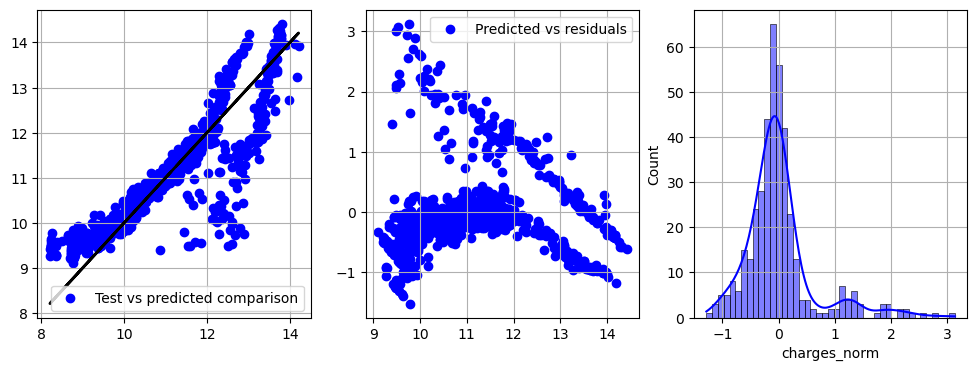

                            OLS Regression Results                            
Dep. Variable:           charges_norm   R-squared:                       0.769
Model:                            OLS   Adj. R-squared:                  0.766
Method:                 Least Squares   F-statistic:                     328.7
Date:              jue., 27 feb. 2025   Prob (F-statistic):          2.23e-124
Time:                        13:23:41   Log-Likelihood:                -399.12
No. Observations:                 401   AIC:                             808.2
Df Residuals:                     396   BIC:                             828.2
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         10.6682      0.037    287.963      0.0

In [55]:
# Escalamiento de los datos
columns_to_scale = ['children', 'age_norm', 'bmi_norm']
scaler = Scaler()
scaler.fit(X_trainf, columns=columns_to_scale)
X_train_scaled = scaler.transform(X_trainf)
X_test_scaled  = scaler.transform(X_testf)

# Entrenamiento del modelo lineal
model = LinearRegression()
model.fit(X_train_scaled, y_trainf)

X_train0 = sm.add_constant(X_train_scaled)
model_stats = sm.OLS(y_trainf, X_train0).fit()
results = model_stats.summary()

# Evaluación del modelo
y_predictions_train = model.predict(X_train_scaled)
y_predictions_test  = model.predict(X_test_scaled)
residuales = y_testf - y_predictions_test
mae_train = mean_absolute_error(y_trainf, y_predictions_train)
mae_test  = mean_absolute_error(y_testf, y_predictions_test)
r2_train = r2_score(y_trainf, y_predictions_train)
r2_test  = r2_score(y_testf, y_predictions_test)

print('*'*60)
print(f'El MAE del modelo en train es de = {mae_train}')
print(f'El MAE del modelo en test es de = {mae_test}')
print('*'*60)
print(f'El R2 del modelo en train es de = {r2_train}')
print(f'El R2 del modelo en test es de = {r2_test}')

# Scatter plot de residuales
fig, ax = plt.subplots(1,3, figsize=(12,4))
ax[0].scatter(y_testf, y_predictions_test, color='blue', label='Test vs predicted comparison')
ax[0].plot(y_testf, y_testf, color='black', linewidth=2)
ax[0].grid()
ax[0].legend()
ax[1].scatter(y_predictions_test, residuales, color='blue', label='Predicted vs residuals')
ax[1].grid()
ax[1].legend()
sns.histplot(residuals, kde=True, color='b', ax=ax[2])
ax[2].grid()
plt.show()

# reporte de significancia
print(results)

Finalmente, observamos como a partir de una menor cantidad de variables obtemenos resultados prácticamente idénticos donde todos los parámetros encontrados poseen significancia estadística.

**<h2 style="color: rgb(71, 207, 228);">Créditos</h2>**

---

**Docente:** Nicolás Castillo Ojeda

**Universidad Pedagógica y Tecnológica de Colombia** - *Diplomado en Inteligencia Artificial - Cohorte I - 2025*


---